In [17]:
import numpy as np
import time
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import skimage
import scipy
from scipy.ndimage import gaussian_filter
from scipy.signal import medfilt
from IPython.display import display, HTML
display(HTML("<style>.container { width:65% !important; }</style>"))

### Clusters

In [18]:
def extract_events_of_interest(labels):
	events = []
	indices = []
	start_idx = None

	for i in range(len(labels)):
		if labels[i] == 1:
			if start_idx is None:
				start_idx = i
			indices.append(i)
		elif start_idx is not None:
			if len(indices) >= 2:
				events.append(indices)
			start_idx = None
			indices = []

	if start_idx is not None and len(indices) >= 1:
		events.append(np.asarray(indices))
	return events

def map_cluster_data(animals, unsupervised_data_full, clusters, beh='agg'):
	
	trials_across_animals = np.zeros((len(clusters), 3, len(animals)))
	trials_across_animals[:] = np.nan
	occupancies_across_animals = trials_across_animals.copy()
	persistence_across_animals = trials_across_animals.copy()
	
	for a, animal in enumerate(animals):
		
		sessions2map = list(unsupervised_data_full.keys())
		sessions2map = [x for x in sessions2map if animal in x]
		for s, session in enumerate(sessions2map):
			sample = unsupervised_data_full[session]
			ntrials, occupancies, persistences = get_unsupervised_trials(sample, clusters)
			trials_across_animals[:, s, a] = ntrials
			occupancies_across_animals[:, s, a] = occupancies
			persistence_across_animals[:, s, a] = persistences

	return trials_across_animals, occupancies_across_animals, persistence_across_animals

def get_unsupervised_trials(session_binary_labels, clusters):
	
	ntrials = np.zeros((len(clusters)))
	occupancies = ntrials.copy()
	persistences = ntrials.copy()
	
	for i in np.arange(len(clusters)):    

		y = session_binary_labels[:, i]
		y = y[~np.isnan(y)]

		events = extract_events_of_interest(y)
		ntrials[i] = len(events)
		if len(events) == 0:
			persistences[i] = 0
		else:
	  	 	persistences[i] = np.nanmedian([len(x)/40 for x in events])
			
		try:
			stacked_events = np.hstack(events)
			occupancies[i] =len(stacked_events)/len(y)
		except ValueError:
			print('Found error!')
			occupancies[i] = 0
			
	return ntrials, occupancies, persistences

def map_cluster_transitions(animals, full_data, clusters, beh='agg'):
	
	transition_matrices = np.zeros((len(clusters), len(clusters), 3, len(animals)))    
	
	for a, animal in enumerate(animals):
		
		sessions2map = list(unsupervised_data_full.keys())
		sessions2map = [x for x in sessions2map if animal in x]
		for s, session in enumerate(sessions2map):
			
			vec = full_data[session]['unsupervised labels'].values.astype(int)
			for i in range(len(vec) - 1):
				if vec[i] != vec[i+1]:  # Exclude same-number transitions
					transition_matrices[vec[i]-1][vec[i+1]-1, s, a] += 1

	row_sums = transition_matrices.sum(axis=1, keepdims=True)
	normalized_transition_matrices = transition_matrices / row_sums
	
	return normalized_transition_matrices

### Defining clusters

In [19]:
# Load data (1mg/kg)
gq_animals = ['8606R_', '8606R2', '8606L', '8605B', '82017L2', '77355R', '77355B', 'GqC1', 'GqC2', 'GqC3', 'GqC4', 'GqC5', 'GqC6', 'GqC7']
full_data = pd.read_pickle('all_Gq_data.pickle')
full_data_ctrl = pd.read_pickle('all_GqCtrl_data.pickle')

# Merge Gq and GqCtrl data
full_data.update(full_data_ctrl)

# Additional formatting
clusters = np.arange(1, 14)  # Assuming clusters are labeled from 1 to 13
n_clusters = len(clusters)

# Make binary labels out of cluster time series
unsupervised_data_full = {}

for key in full_data.keys():
	sample = full_data[key]['unsupervised labels']
	unsupervised_binary_labels = np.zeros((len(sample), len(clusters)))
	for i, label in enumerate(sample):
		unsupervised_binary_labels[i, int(label)-1] = 1
	unsupervised_data_full[key] = unsupervised_binary_labels

# Extract trial info
cluster_trials, cluster_occupancies, cluster_persistence = map_cluster_data(gq_animals, unsupervised_data_full, clusters)

# Separate Gq and GqCtrl data
gq_1mg_cluster_trials = cluster_trials[:, :, :7]
gq_1mg_cluster_occupancies = cluster_occupancies[:, :, :7]
gq_1mg_cluster_persistence = cluster_persistence[:, :, :7]
gqctrl_1mg_cluster_trials = cluster_trials[:, :, 7:14]
gqctrl_1mg_cluster_occupancies = cluster_occupancies[:, :, 7:14]
gqctrl_1mg_cluster_persistence = cluster_persistence[:, :, 7:14]

Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!
Found error!


In [20]:
# Post-histology correction
# ── Corrected group assignments ───────────────────────────────────────────────
# 8605B (index 3 in gq_animals, had no expression) → move to ctrl
# GqC3  (index 2 in ctrl slice, i.e. index 9 in gq_animals, recording got ruined) → remove

gq_animals_corrected   = ['8606R_', '8606R2', '8606L', '82017L2',
                           '77355R', '77355B']               # 8605B removed
ctrl_animals_corrected = ['GqC1', 'GqC2', 'GqC4', 'GqC5',
                           'GqC6', 'GqC7', '8605B']          # GqC3 removed, 8605B added

# ── Gq arrays: remove 8605B (index 3) ────────────────────────────────────────
gq_1mg_cluster_trials       = np.delete(cluster_trials[:,       :, :7], 3, axis=2)
gq_1mg_cluster_occupancies  = np.delete(cluster_occupancies[:,  :, :7], 3, axis=2)
gq_1mg_cluster_persistence  = np.delete(cluster_persistence[:,  :, :7], 3, axis=2)

# ── Ctrl arrays: remove GqC3 (index 2), append 8605B (index 3 from original) ─
_ctrl_trials      = np.delete(cluster_trials[:,      :, 7:14], 2, axis=2)
_ctrl_occupancies = np.delete(cluster_occupancies[:, :, 7:14], 2, axis=2)
_ctrl_persistence = np.delete(cluster_persistence[:, :, 7:14], 2, axis=2)

_8605B_trials      = cluster_trials[:,      :, 3:4]   # keep as (n,m,1)
_8605B_occupancies = cluster_occupancies[:, :, 3:4]
_8605B_persistence = cluster_persistence[:, :, 3:4]

gqctrl_1mg_cluster_trials      = np.concatenate([_ctrl_trials,      _8605B_trials],      axis=2)
gqctrl_1mg_cluster_occupancies = np.concatenate([_ctrl_occupancies, _8605B_occupancies], axis=2)
gqctrl_1mg_cluster_persistence = np.concatenate([_ctrl_persistence, _8605B_persistence], axis=2)

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'Gq   animals ({len(gq_animals_corrected)}): {gq_animals_corrected}')
print(f'Ctrl animals ({len(ctrl_animals_corrected)}): {ctrl_animals_corrected}')
print(f'gq_1mg_cluster_occupancies   shape: {gq_1mg_cluster_occupancies.shape}')
print(f'gqctrl_1mg_cluster_occupancies shape: {gqctrl_1mg_cluster_occupancies.shape}')

Gq   animals (6): ['8606R_', '8606R2', '8606L', '82017L2', '77355R', '77355B']
Ctrl animals (7): ['GqC1', 'GqC2', 'GqC4', 'GqC5', 'GqC6', 'GqC7', '8605B']
gq_1mg_cluster_occupancies   shape: (13, 3, 6)
gqctrl_1mg_cluster_occupancies shape: (13, 3, 7)


In [21]:
sns.set_context(rc={'lines.linewidth': 2.5,
					'axes.labelsize': 25,
					'axes.titlesize': 19.200000000000003,
					'font.size': 25,
					'xtick.major.width': 8,
					'ytick.major.width': 8,
					'xtick.major.size':6,
					'ytick.major.size':6,
					'axes.linewidth':4})

In [22]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

def add_significance_brackets(ax, positions, data_to_plot, results, y_offset_factor=0.1, center_height=0.5):
    """
    Add significance brackets above boxplots based on statistical results.
    
    Parameters:
    -----------
    ax : matplotlib axis
        The axis to add brackets to
    positions : list
        x-positions of the boxplots
    data_to_plot : list
        Data for each group to determine y-limits
    results : dict
        Statistical results from run_comprehensive_stats
    y_offset_factor : float
        Factor to determine bracket height above data
    """
    if results is None or 'gq_vs_gqctrl' not in results:
        return
    
    # Get max
    max_y = max([np.max(data) for data in data_to_plot])

    # Define significance symbols
    def get_significance_symbol(p_val):
        if p_val <= 0.001:
            return '***'
        elif p_val <= 0.01:
            return '**'
        elif p_val <= 0.05:
            return '*'
        elif p_val <= 0.1:
            return '#'  # trend symbol
        else:
            return 'ns'
    
    # Only one comparison now: Gq vs GqCtrl
    if 'gq_vs_gqctrl' in results:
        p_val = results['gq_vs_gqctrl']['p_corrected']
        sig_symbol = get_significance_symbol(p_val)
        
        if sig_symbol != 'ns':
            x1, x2 = positions[0], positions[1]
            
            # Get line width from axes to match bracket thickness
            axes_linewidth = ax.spines['bottom'].get_linewidth() - 1
            bracket_linewidth = max(axes_linewidth, 1.5)
            
            # Draw bracket with thicker lines
            bracket_drop = center_height * 0.025
            ax.plot([x1, x1, x2, x2], 
                   [center_height - bracket_drop, center_height, 
                    center_height, center_height - bracket_drop], 
                   'k-', linewidth=bracket_linewidth)
            
            # Add significance symbol
            text_offset = center_height * 0.0001
            ax.text((x1 + x2) / 2, center_height + text_offset, 
                   sig_symbol, ha='center', va='bottom', fontsize=25, fontweight='bold')

### stats validation of Gq behaviors with significance brackets
plt.close()
mean_func = np.mean
n=1

### data prep
# Gq_conserved = [0, 1, 3, 4, 5, 6]
gq_trials, gq_occupancies, gq_persistence = gq_1mg_cluster_trials[:, :n, :].reshape(13, 6*n), gq_1mg_cluster_occupancies[:, :n, :].reshape(13, 6*n), gq_1mg_cluster_persistence[:, :n, :].reshape(13, 6*n)
gqctrl_trials, gqctrl_occupancies, gqctrl_persistence = gqctrl_1mg_cluster_trials[:, :n, :].reshape(13, 7*n), gqctrl_1mg_cluster_occupancies[:, :n, :].reshape(13, 7*n), gqctrl_1mg_cluster_persistence[:, :n, :].reshape(13, 7*n)

In [23]:
def map_cluster_transitions(animals, full_data, clusters):
    """
    Map cluster-to-cluster transitions for given animals.
    
    Parameters:
    -----------
    animals : list
        List of animal IDs
    full_data : dict
        Dictionary with session keys containing DataFrames with 'unsupervised labels'
    clusters : array
        Array of cluster numbers
    
    Returns:
    --------
    normalized_transition_matrices : ndarray
        Shape: (n_clusters, n_clusters, n_sessions, n_animals)
        Normalized transition probabilities between clusters
    """
    
    # Initialize transition matrices (13 clusters x 13 clusters x 3 sessions x n_animals)
    transition_matrices = np.zeros((len(clusters), len(clusters), 3, len(animals)))
    
    for a, animal in enumerate(animals):
        
        # Get sessions for this animal
        sessions2map = [x for x in full_data.keys() if animal in x]
        
        for s, session in enumerate(sessions2map):
            
            vec = full_data[session]['unsupervised labels'].values.astype(int)
            for i in range(len(vec) - 1):
                if vec[i] != vec[i+1]:  # Exclude same-number transitions
                    transition_matrices[vec[i]-1, vec[i+1]-1, s, a] += 1

    # Normalize by row sums to get transition probabilities
    row_sums = np.nansum(transition_matrices, axis=1, keepdims=True)
    normalized_transition_matrices = transition_matrices / row_sums
    
    return normalized_transition_matrices

# Usage for 1mg data

full_data = pd.read_pickle('all_Gq_data.pickle')
full_data_ctrl = pd.read_pickle('all_GqCtrl_data.pickle')
full_data.update(full_data_ctrl)

gq_1mg_transitions = map_cluster_transitions(
	['8606R_', '8606R2', '82017L2', '8606L', '8605B', '77355R', '77355B'], 
	full_data,
	clusters
)

gqctrl_1mg_transitions = map_cluster_transitions(
	['GqC1', 'GqC2', 'GqC3', 'GqC4', 'GqC5', 'GqC6', 'GqC7'],
	full_data,
	clusters
)



C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_53944\3667571397.py:38: RuntimeWarning: invalid value encountered in divide
  normalized_transition_matrices = transition_matrices / row_sums


In [24]:
# Post-histo cleanup

gq_1mg_transitions = map_cluster_transitions(
    ['8606R_', '8606R2', '82017L2', '8606L', '77355R', '77355B'],  # 8605B removed
    full_data, clusters
)

gqctrl_1mg_transitions = map_cluster_transitions(
    ['GqC1', 'GqC2', 'GqC4', 'GqC5', 'GqC6', 'GqC7'],  # GqC3 removed
    full_data, clusters
)

# ── Append 8605B to ctrl ──────────────────────────────────────────────────────
transitions_8605B = map_cluster_transitions(
    ['8605B'], full_data, clusters
)  # shape (13, 13, 3, 1)

gqctrl_1mg_transitions = np.concatenate(
    [gqctrl_1mg_transitions, transitions_8605B], axis=3
)

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'Gq   transitions shape: {gq_1mg_transitions.shape}')    # (13,13,3,6)
print(f'Ctrl transitions shape: {gqctrl_1mg_transitions.shape}') # (13,13,3,7)

Gq   transitions shape: (13, 13, 3, 6)
Ctrl transitions shape: (13, 13, 3, 7)


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_53944\3667571397.py:38: RuntimeWarning: invalid value encountered in divide
  normalized_transition_matrices = transition_matrices / row_sums


In [25]:
# Group transition matrix differences for Gq vs GqCtrl
from scipy.spatial.distance import jensenshannon
import matplotlib.colors as colors

indices = np.arange(n_clusters)

# Extract relevant sessions for each group and dose
gq_1mg_transitions_2_map = gq_1mg_transitions[np.ix_(indices, indices, np.arange(gq_1mg_transitions.shape[2]), np.arange(gq_1mg_transitions.shape[3]))][:, :, 0, :]
gqctrl_1mg_transitions_2_map = gqctrl_1mg_transitions[np.ix_(indices, indices, np.arange(gqctrl_1mg_transitions.shape[2]), np.arange(gqctrl_1mg_transitions.shape[3]))][:, :, 0, :]

# Replace NaN with 0
gq_1mg_transitions_2_map = np.where(np.isnan(gq_1mg_transitions_2_map), np.nan, gq_1mg_transitions_2_map)
gqctrl_1mg_transitions_2_map = np.where(np.isnan(gqctrl_1mg_transitions_2_map), np.nan, gqctrl_1mg_transitions_2_map)


### Similarity analyses

In [29]:
# Retrieve manuscript data from files
data_dir = './'  # or specify your directory

# Load transition matrices
transitions_file = os.path.join(data_dir, 'all_transitions.npz')
transitions_data = np.load(transitions_file)
agg_transitions_2_map = transitions_data['agg_transitions_2_map']
obs_transitions_2_map = transitions_data['obs_transitions_2_map']
non_transitions_2_map = transitions_data['non_transitions_2_map']
xpo_transitions_2_map = transitions_data['xpo_transitions_2_map']
all_transitions = transitions_data['all_transitions']

# Load occupancy data
occupancy_file = os.path.join(data_dir, 'occupancy_data.npz')
occupancy_data = np.load(occupancy_file)
agg_occupancy_2_map = occupancy_data['agg_HF_occupancies']
obs_occupancy_2_map = occupancy_data['obs_HF_occupancies']
non_occupancy_2_map = occupancy_data['non_HF_occupancies']
xpo_occupancy_2_map = occupancy_data['xpo_HF_occupancies']

# Load persistence data
persistence_file = os.path.join(data_dir, 'persistence_data.npz')
persistence_data = np.load(persistence_file)
agg_persistence_2_map = persistence_data['agg_HF_persistence']
obs_persistence_2_map = persistence_data['obs_HF_persistence']
non_persistence_2_map = persistence_data['non_HF_persistence']
xpo_persistence_2_map = persistence_data['xpo_HF_persistence']

In [30]:
# Format data for comparisons (NON vs Gq-Ctrl and Gq-OBS)

from scipy.spatial.distance import jensenshannon
from scipy.stats import ks_2samp, mannwhitneyu
import seaborn as sns
from scipy.spatial.distance import euclidean

# Prepare Gq/GqCtrl data (using first session)
n = 0

# Get occupancy data for Gq and GqCtrl
gq_occupancies = gq_1mg_cluster_occupancies[:, n, :].reshape(13, 1, 6)  # Shape: (13, 1, 6)
gqctrl_occupancies = gqctrl_1mg_cluster_occupancies[:, n, :].reshape(13, 1, 7)  # Shape: (13, 1, 6)

# Get OBS and NON occupancies from last 3 sessions
obs_HF_occupancies = obs_occupancy_2_map[:, -3:, :]  # Shape: (13, 3, 9)
non_HF_occupancies = non_occupancy_2_map[:, -3:, :]  # Shape: (13, 3, 10)
agg_HF_occupancies = agg_occupancy_2_map[:, -3:, :]  # Shape: (13, 3, 10)

# Get persistence data for Gq and GqCtrl
gq_persistence = gq_1mg_cluster_persistence[:, 0, :].reshape(13,1,6)  # Shape: (13, 1, 6)
gqctrl_persistence = gqctrl_1mg_cluster_persistence[:, 0, :].reshape(13,1,7)  # Shape: (13, 1, 7)

# Get OBS and NON persistence from last 3 sessions
obs_HF_persistence = obs_persistence_2_map[:, -3:, :]  # Shape: (13, 3, 9)
non_HF_persistence = non_persistence_2_map[:, -3:, :]  # Shape: (13, 3, 10)
agg_HF_persistence = agg_persistence_2_map[:, -3:, :]  # Shape: (13, 3, 10)

# Get transition data for Gq and GqCtrl
gq_transitions = gq_1mg_transitions[:, :, n, :].reshape(13,13,1,6)  # Shape: (13, 13, 1, 6)
gqctrl_transitions = gqctrl_1mg_transitions[:, :, n, :].reshape(13,13,1,7)  # Shape: (13, 13, 1, 7)

# Get OBS and NON transitions from last 3 sessions
obs_HF_transitions = obs_transitions_2_map[:, :, -3:, :]  # Shape: (13, 13, 3, 9)
non_HF_transitions = non_transitions_2_map[:, :, -3:, :]  # Shape: (13, 13, 3, 10)
agg_HF_transitions = agg_transitions_2_map[:, :, -3:, :]  # Shape: (13, 13, 3, 10)

# Replace NaN with 0 for transitions
gq_transitions = np.where(np.isnan(gq_transitions), 0, gq_transitions)
gqctrl_transitions = np.where(np.isnan(gqctrl_transitions), 0, gqctrl_transitions)
obs_HF_transitions = np.where(np.isnan(obs_HF_transitions), 0, obs_HF_transitions)
non_HF_transitions = np.where(np.isnan(non_HF_transitions), 0, non_HF_transitions)
agg_HF_transitions = np.where(np.isnan(agg_HF_transitions), 0, agg_HF_transitions)

# Get NON and AGG data from last 3 sessions
non_HF_occupancies = non_occupancy_2_map[:, -3:, :]
agg_HF_occupancies = agg_occupancy_2_map[:, -3:, :]
non_HF_persistence = non_persistence_2_map[:, -3:, :]
agg_HF_persistence = agg_persistence_2_map[:, -3:, :]
non_HF_transitions = non_transitions_2_map[:, :, -3:, :]
agg_HF_transitions = agg_transitions_2_map[:, :, -3:, :]


Stratified, per-NON-animal JS distance — GQ vs GqCtrl (paired by NON identity, n=8)
Occupancy      paired t-test            stat= -16.5584 df=   7.0 p=3.5772e-07   ***  n=8
Transitions    paired t-test            stat=  -4.0943 df=   7.0 p=2.3030e-03    **  n=8


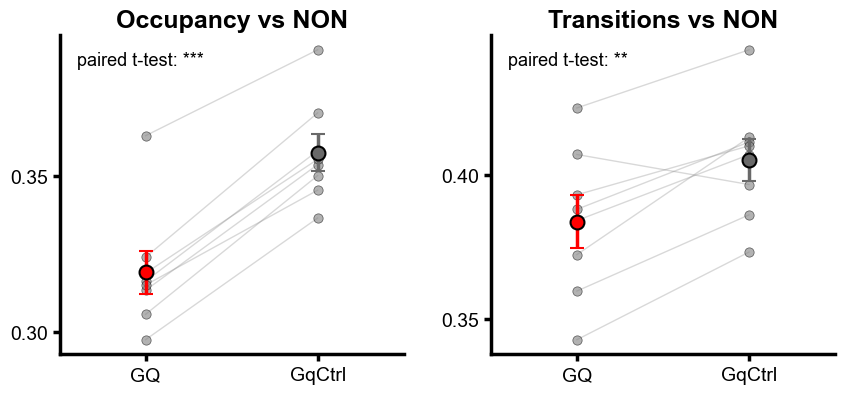

In [41]:
# Calculate JS divergence to NON animals

from scipy.spatial.distance import jensenshannon
from scipy.stats import shapiro, ttest_rel, wilcoxon, sem

def get_sig_stars(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

CATEGORY_INDICES = {
    'conflict':      [0, 1, 2, 3],
    'investigative': [4, 6, 7, 8],
    'asocial':       [5, 9, 10, 11, 12],
}

def per_animal_stratified_js_occupancy(query_occ, ref_occ, category_indices):
    """
    Category-stratified JS distance, one value per QUERY animal, averaged
    over query sessions, reference sessions, reference animals, and
    categories (categories weighted equally). query_occ/ref_occ need not
    share the same session count — each array's own session axis is used.
    """
    n_animals_q, n_sess_q = query_occ.shape[-1], query_occ.shape[1]
    n_animals_r, n_sess_r = ref_occ.shape[-1], ref_occ.shape[1]

    per_category_vals = []
    for cat_name, idx in category_indices.items():
        sub_q, sub_r = query_occ[idx, :, :], ref_occ[idx, :, :]
        animal_vals = np.full(n_animals_q, np.nan)

        for aq in range(n_animals_q):
            dists_this_animal = []
            for sq in range(n_sess_q):
                v1_raw = sub_q[:, sq, aq]
                denom1 = np.nansum(v1_raw)
                if denom1 == 0:
                    continue
                v1 = v1_raw / denom1
                for ar in range(n_animals_r):
                    for sr in range(n_sess_r):
                        v2_raw = sub_r[:, sr, ar]
                        denom2 = np.nansum(v2_raw)
                        if denom2 == 0:
                            continue
                        dists_this_animal.append(jensenshannon(v1, v2_raw / denom2))
            if dists_this_animal:
                animal_vals[aq] = np.nanmean(dists_this_animal)
        per_category_vals.append(animal_vals)

    return np.nanmean(np.stack(per_category_vals, axis=0), axis=0)

def per_animal_stratified_js_transitions(query_trans, ref_trans, category_indices):
    """
    Same as above, but for transition matrices: each category restricts to
    its FROM-state rows across all TO-states, flattened before normalizing.
    """
    n_animals_q, n_sess_q = query_trans.shape[-1], query_trans.shape[2]
    n_animals_r, n_sess_r = ref_trans.shape[-1], ref_trans.shape[2]

    per_category_vals = []
    for cat_name, idx in category_indices.items():
        sub_q, sub_r = query_trans[idx, :, :, :], ref_trans[idx, :, :, :]
        animal_vals = np.full(n_animals_q, np.nan)

        for aq in range(n_animals_q):
            dists_this_animal = []
            for sq in range(n_sess_q):
                v1_raw = sub_q[:, :, sq, aq].flatten()
                denom1 = np.nansum(v1_raw)
                if denom1 == 0:
                    continue
                v1 = v1_raw / denom1
                for ar in range(n_animals_r):
                    for sr in range(n_sess_r):
                        v2_raw = sub_r[:, :, sr, ar].flatten()
                        denom2 = np.nansum(v2_raw)
                        if denom2 == 0:
                            continue
                        dists_this_animal.append(jensenshannon(v1, v2_raw / denom2))
            if dists_this_animal:
                animal_vals[aq] = np.nanmean(dists_this_animal)
        per_category_vals.append(animal_vals)

    return np.nanmean(np.stack(per_category_vals, axis=0), axis=0)


# ── Per-NON-animal distances (NON = fixed query cohort, n=8, paired) ─────────
non_vs_gq_occ     = per_animal_stratified_js_occupancy(non_HF_occupancies, gq_occupancies, CATEGORY_INDICES)
non_vs_gqctrl_occ = per_animal_stratified_js_occupancy(non_HF_occupancies, gqctrl_occupancies, CATEGORY_INDICES)

non_vs_gq_trans     = per_animal_stratified_js_transitions(non_HF_transitions, gq_transitions, CATEGORY_INDICES)
non_vs_gqctrl_trans = per_animal_stratified_js_transitions(non_HF_transitions, gqctrl_transitions, CATEGORY_INDICES)


def compute_df_for_test(test_name, n):
    return n - 1 if test_name == 'paired t-test' else np.nan

def paired_test(a, b, alternative='less', alpha=0.05):
    mask = ~np.isnan(a) & ~np.isnan(b)
    a_clean, b_clean = a[mask], b[mask]
    n = len(a_clean)
    if n < 3:
        return {'test': 'n/a', 'stat': np.nan, 'df': np.nan, 'p': np.nan,
                'n': n, 'a': a_clean, 'b': b_clean}
    diffs = a_clean - b_clean
    _, p_diff = shapiro(diffs)
    if p_diff > alpha:
        stat, p = ttest_rel(a_clean, b_clean, alternative=alternative)
        test = 'paired t-test'
    else:
        try:
            stat, p = wilcoxon(a_clean, b_clean, alternative=alternative)
        except ValueError:
            stat, p = np.nan, np.nan
        test = 'Wilcoxon signed-rank'
    return {'test': test, 'stat': stat, 'df': compute_df_for_test(test, n), 'p': p,
            'n': n, 'a': a_clean, 'b': b_clean}


results_occ   = paired_test(non_vs_gq_occ, non_vs_gqctrl_occ)
results_trans = paired_test(non_vs_gq_trans, non_vs_gqctrl_trans)

print(f'\n{"="*90}')
print(f'Stratified, per-NON-animal JS distance — GQ vs GqCtrl (paired by NON identity, n=8)')
print(f'{"="*90}')
for label, r in [('Occupancy', results_occ), ('Transitions', results_trans)]:
    stat_s = f'{r["stat"]:.4f}' if not np.isnan(r['stat']) else 'n/a'
    df_s   = f'{r["df"]:.1f}'   if not np.isnan(r['df'])   else 'n/a'
    print(f'{label:<14} {r["test"]:<24} stat={stat_s:>9} df={df_s:>6} '
          f'p={r["p"]:.4e}  {get_sig_stars(r["p"]):>4}  n={r["n"]}')
print(f'{"="*90}')

# ── 1×2 mean ± SEM plots, individuals (NON identity, gray) + connecting lines ─
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

panel_data = [
    ('Occupancy',   non_vs_gq_occ,   non_vs_gqctrl_occ,   results_occ),
    ('Transitions', non_vs_gq_trans, non_vs_gqctrl_trans, results_trans),
]

for ax, (title, a, b, r) in zip(axes, panel_data):
    positions = [1, 2]

    for i in range(r['n']):
        ax.plot(positions, [r['a'][i], r['b'][i]], color='gray', alpha=0.3, linewidth=1, zorder=1)
    for j, data in enumerate([r['a'], r['b']]):
        ax.scatter(np.full(len(data), positions[j]), data,
                   color='gray', edgecolor='black', linewidths=0.5, s=45, alpha=0.6, zorder=3)

    for j, (data, c) in enumerate(zip([r['a'], r['b']], ['red', 'dimgray'])):
        mean_val, sem_val = np.mean(data), sem(data)
        ax.errorbar(positions[j], mean_val, yerr=sem_val,
                   fmt='o', color=c, markeredgecolor='black', markersize=10,
                   markeredgewidth=1.5, elinewidth=2.5, capsize=5, capthick=2.5, zorder=5)

    ax.set_xlim(0.5, 2.5)
    ax.set_xticks(positions)
    ax.set_xticklabels(['GQ', 'GqCtrl'], fontsize=16, fontfamily='Arial')
    ax.set_title(f'{title} vs NON', fontsize=18, fontfamily='Arial', fontweight='bold')
    ax.text(0.05, 0.95, f'{r["test"]}: {get_sig_stars(r["p"])}',
            transform=ax.transAxes, fontsize=13, va='top', fontfamily='Arial')
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial'); tick.set_fontsize(14)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    ax.tick_params(length=5, width=2.5)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('.\\figures\\fig5_JS_divergence_GQ_GqCtrl_vs_NON_stratified.svg', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# ── Source data export: 5o ────────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []
for panel_label, a, b, r in [
    ('Occupancy',   results_occ['a'],   results_occ['b'],   results_occ),
    ('Transitions', results_trans['a'], results_trans['b'], results_trans),
]:
    for v in a:
        rows.append({
            'panel': panel_label,
            'series': 'GQ',
            'js_distance': v,
            'test': r['test'],
            'stat': r['stat'],
            'df': r['df'],
            'p_value': r['p'],
            'n': r['n'],
        })
    for v in b:
        rows.append({
            'panel': panel_label,
            'series': 'GqCtrl',
            'js_distance': v,
            'test': r['test'],
            'stat': r['stat'],
            'df': r['df'],
            'p_value': r['p'],
            'n': r['n'],
        })

sourceData_5o = pd.DataFrame(rows)
sourceData_5o.to_csv('./sourceData/5o.csv', index=False)

### Comparing embeddings

In [25]:
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from matplotlib import colors
from mpl_toolkits.axes_grid1 import ImageGrid
from matplotlib.colors import ListedColormap
from matplotlib.cm import get_cmap

def open_sessions(path):
	with open(path, 'rb') as handle:
		feats = pickle.load(handle)
	return feats

def select_features(feats, feats_list):
	
	for feat_day in feats.keys():
		feats[feat_day] = feats[feat_day][feats_list]
		
	return feats

def map_density(X_embedded, bins=50, sigma=2.5, percentile=30, cm = 'nipy_spectral', watershed_line=True, wt=0):

	# Find local maxima as "seeds" for the watershed transform
	all_map_density, xe, ye = heatmap(X_embedded, bins=bins, sigma=sigma)
	density_cutoff = np.percentile(all_map_density, percentile)
	density_mask = all_map_density > density_cutoff
	local_maxes = peak_local_max(all_map_density, indices=False)
	local_maxes[np.logical_not(density_mask)] = False
	markers, n_peaks = scipy.ndimage.label(local_maxes)

	# Compute watershed transform
	
	labeled_map = watershed(-all_map_density, markers, watershed_line=False)
	labeled_map = labeled_map.astype('float64')
	
	labeled_map_viz = watershed(-all_map_density, markers, watershed_line=watershed_line)
	labeled_map_viz = labeled_map_viz.astype('float64')

	viz = all_map_density
	viz[labeled_map_viz==0]=wt
	plt.figure(figsize=(10,10))
	plt.imshow(all_map_density.T, cmap=cm,origin='lower')
	
	plt.axis('off')
	plt.show()
	
	###
	
	plt.figure(figsize=(10,10))
	plt.imshow(labeled_map.T, cmap='rainbow',origin='lower')
	plt.axis('off')

	for i in np.unique(labeled_map.flatten()):
		x=np.mean(np.where(labeled_map==i)[0])
		y=np.mean(np.where(labeled_map==i)[1])
		plt.text(x,y,int(i),size=20)

	plt.show()
	
	return labeled_map, all_map_density, xe, ye, local_maxes

def heatmap(data, axlims=None, bins=100, normed=True, sigma=0.0):
	
	# Initial histogram
	heatmap, xedges, yedges = np.histogram2d(data[:,0], data[:, 1], bins=bins, range=axlims, normed=normed)
	
	# Convolve with Gaussian
	heatmap = gaussian_filter(heatmap, sigma=sigma)
	
	return heatmap, xedges, yedges

def embedding_labels(embeddings, labeled_map, xe, ye, bins=100):

	labels = {}

	map_shape=(bins,bins)
	xmin=min(xe)
	xmax=max(xe)
	ymin=min(ye)
	ymax=max(ye)

	for k, e in embeddings.items():
		
		def to_coords(xy):
			
			x = (xy[0] - xmin) / (xmax - xmin) * map_shape[0]
			y = (xy[1] - ymin) / (ymax - ymin) * map_shape[1]
			if x >= map_shape[0]:
				x = map_shape[0]-1
			if y >= map_shape[1]:
				y = map_shape[1]-1
			if x < 0:
				x=0
			if y < 0:
				y=0
			return int(x), int(y)

		labels[k] = np.array([labeled_map[to_coords(point)] for point in e])
		
	return labels

def transfer_embedding(data2move, target_data):
    for key in data2move.keys():
        sample = data2move[key]

        # Get rid of outliers that will break watershed in y
        y = sample[:, 1]
        y = np.where(y > 7, np.nan, y)
        nan_indices_y = np.where(np.isnan(y))[0]
        stretches_y = np.split(nan_indices_y, np.where(np.diff(nan_indices_y) != 1)[0] + 1)
        for stretch in stretches_y:
            if len(stretch) > 0:
                random_values_y = np.random.normal(loc=mean_y, scale=std_dev_y, size=len(stretch))
                y[stretch] = random_values_y
        sample[:, 1] = y

        # Process x
        x = sample[:, 0]
        x = np.where(x > 16, np.nan, x)
        nan_indices_x = np.where(np.isnan(x))[0]
        stretches_x = np.split(nan_indices_x, np.where(np.diff(nan_indices_x) != 1)[0] + 1)
        for stretch in stretches_x:
            if len(stretch) > 0:
                random_values_x = np.random.normal(loc=mean_x, scale=std_dev_x, size=len(stretch))
                x[stretch] = random_values_x
        sample[:, 0] = x

        target_data[key] = sample

    return target_data


file1 = 'C:\\Users\\FalknerLab\\Desktop\\UMAP_embeddings_behavior\\umap_embeddings_unified.pickle'
file2 = 'C:\\Users\\FalknerLab\\Desktop\\UMAP_embeddings_behavior\\umap_embeddings_Gq.pickle'
mf_data = open_sessions(file1)
gq_data = open_sessions(file2)
# new_data = transfer_embedding(mf_data, gq_data)

In [27]:
for key in gq_data.keys():
    sample = gq_data[key]

    # Process y
    y = sample[:, 1]
    y = np.where(y > 7, np.nan, y)
    mean_y = np.nanmean(y)
    std_dev_y = np.nanstd(y)
    nan_indices_y = np.where(np.isnan(y))[0]
    stretches_y = np.split(nan_indices_y, np.where(np.diff(nan_indices_y) != 1)[0] + 1)
    for stretch in stretches_y:
        if len(stretch) > 0:
            random_values_y = np.random.normal(loc=mean_y, scale=std_dev_y, size=len(stretch))
            y[stretch] = random_values_y
    sample[:, 1] = y

    # Process x
    x = sample[:, 0]
    x = np.where(x > 16, np.nan, x)
    mean_x = np.nanmean(x)
    std_dev_x = np.nanstd(x)
    nan_indices_x = np.where(np.isnan(x))[0]
    stretches_x = np.split(nan_indices_x, np.where(np.diff(nan_indices_x) != 1)[0] + 1)
    for stretch in stretches_x:
        if len(stretch) > 0:
            random_values_x = np.random.normal(loc=mean_x, scale=std_dev_x, size=len(stretch))
            x[stretch] = random_values_x
    sample[:, 0] = x

    gq_data[key] = sample


Generating embedding figs

In [81]:
new_data = data.copy()

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_19316\1258109736.py:27: FutureWarning: indices argument is deprecated and will be removed in version 0.20. To avoid this warning, please do not use the indices argument. Please see peak_local_max documentation for more details.
  local_maxes = peak_local_max(all_map_density, indices=False)


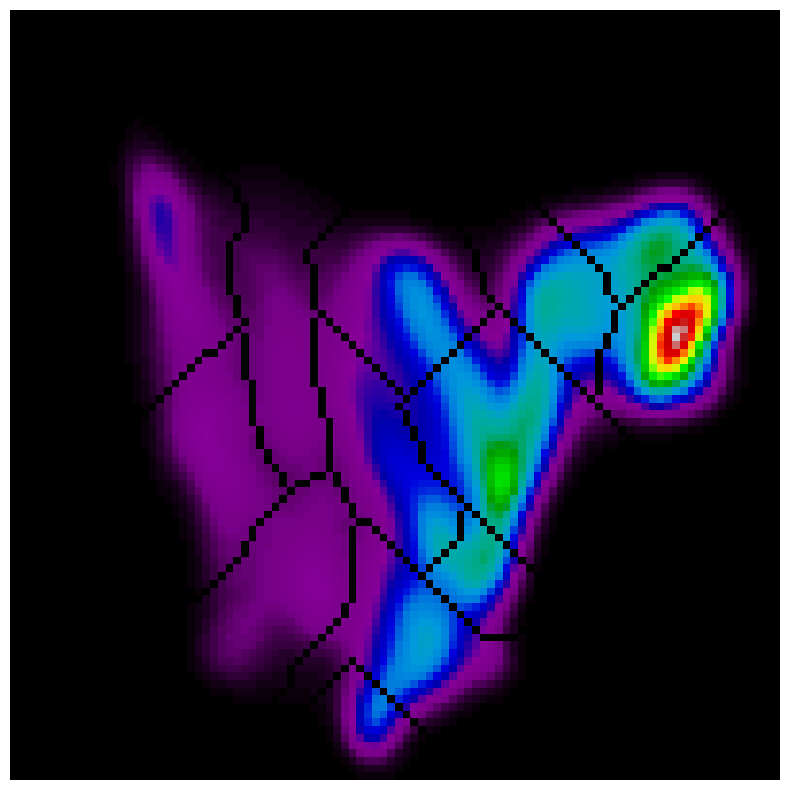

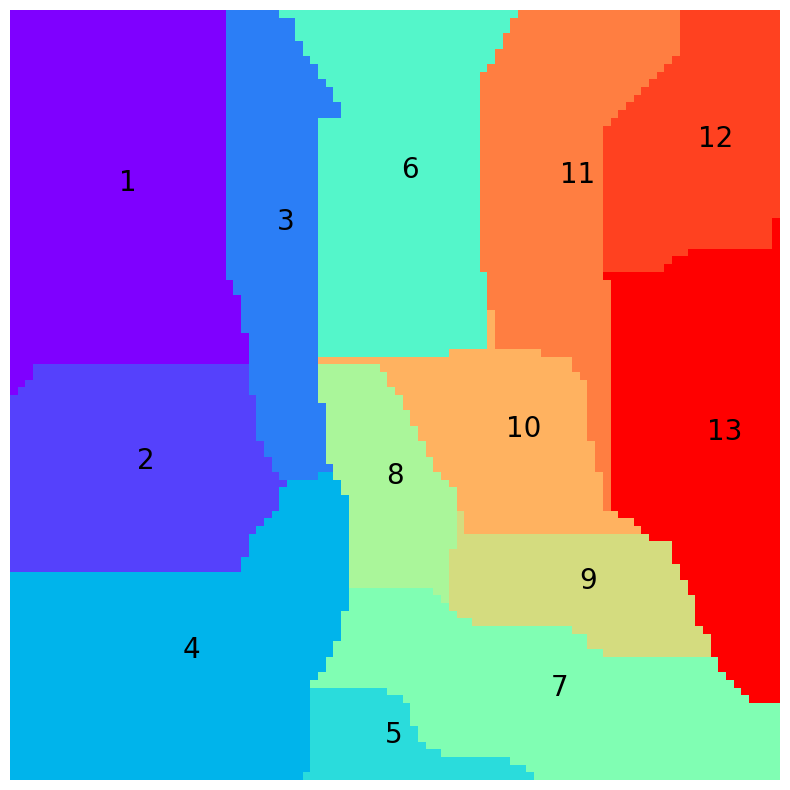

In [82]:
# concatenate all embeddings
final_embs = []
for key in data.keys():
	final_embs.append(new_data[key])
final_embs = np.row_stack(final_embs)

# run watershed on concatenated embeddings

### for earlier analysis, feats 3 bins=100, percentile=74.4, sigma=2
# labeled_map, density, xe, ye, _ = map_density(final_embs, bins=100, percentile=73.8, sigma=2.1) 
### for new analysis with new embs, feats 3 bins=100, percentile=73.8, sigma=2.1
labeled_map, density, xe, ye, lmaxes = map_density(final_embs, bins=100, percentile=75, sigma=1.8) # preprint: 73.8, sigma=2.1, review: 75, sigma=1.8
labels = embedding_labels(data, labeled_map, xe, ye, bins=100)

# derive final label set
final_labels = []
for key in labels.keys():
	final_labels.append(labels[key])
final_labels = np.concatenate(final_labels)

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_19316\829870393.py:11: FutureWarning: indices argument is deprecated and will be removed in version 0.20. To avoid this warning, please do not use the indices argument. Please see peak_local_max documentation for more details.
  local_maxes = peak_local_max(all_map_density, indices=False)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_19316\829870393.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_cmap = get_cmap('nipy_spectral', 126)


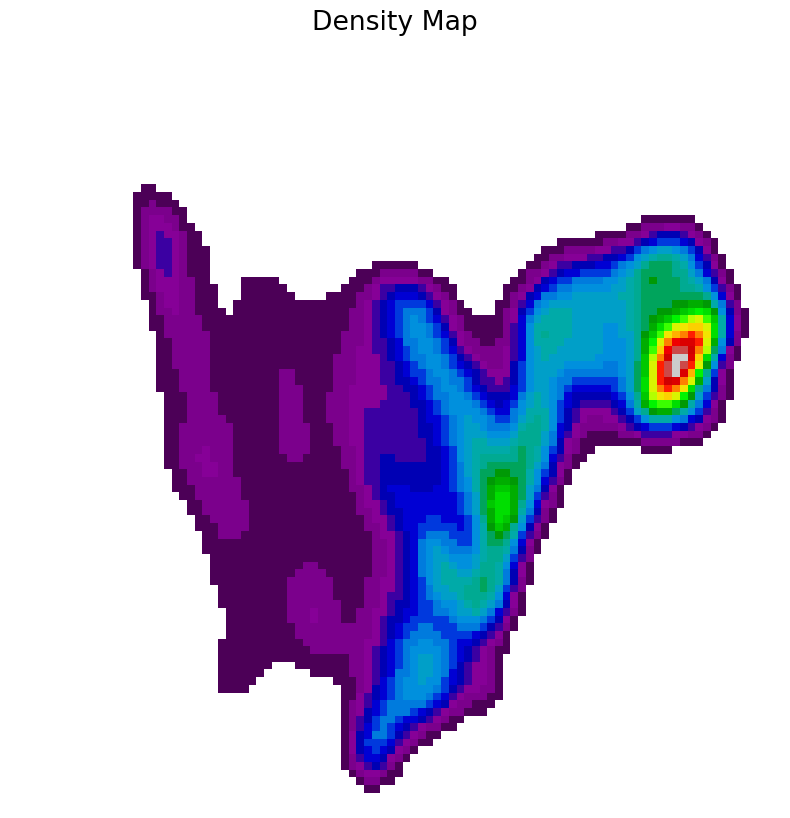

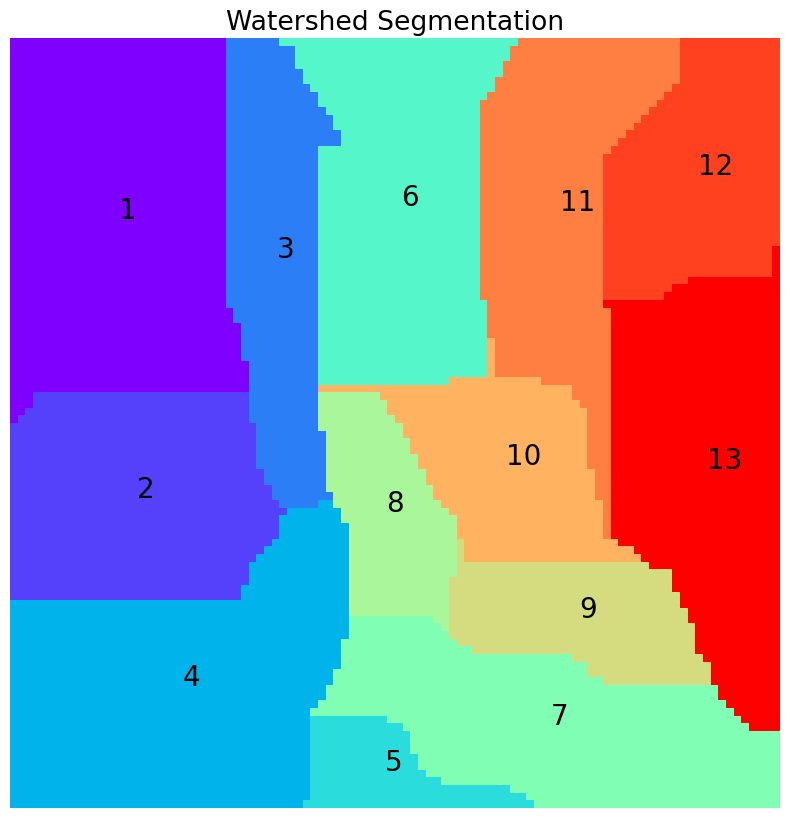

In [78]:
# Apply to Gq/GqCtrl data

def create_watershed_segmentation(X_embedded_reference, bins=50, sigma=2.5, percentile=30):
    """
    Create watershed segmentation from reference embedding that can be applied to other embeddings
    """
    # Find local maxima as "seeds" for the watershed transform
    all_map_density, xe, ye = heatmap(X_embedded_reference, bins=bins, sigma=sigma)
    density_cutoff = np.percentile(all_map_density, percentile)
    density_mask = all_map_density > density_cutoff
    local_maxes = peak_local_max(all_map_density, indices=False)
    local_maxes[np.logical_not(density_mask)] = False
    markers, n_peaks = scipy.ndimage.label(local_maxes)

    # Compute watershed transform
    labeled_map = watershed(-all_map_density, markers, watershed_line=False)
    labeled_map = labeled_map.astype('float64')
    
    return labeled_map, all_map_density, xe, ye, local_maxes

def apply_watershed_segmentation(X_embedded_target, labeled_map, xe, ye, bins=100):
    """
    Apply existing watershed segmentation to new embedding data
    """
    labels = {}
    
    map_shape = (bins, bins)
    xmin = min(xe)
    xmax = max(xe)
    ymin = min(ye)
    ymax = max(ye)
    
    def to_coords(xy):
        x = (xy[0] - xmin) / (xmax - xmin) * map_shape[0]
        y = (xy[1] - ymin) / (ymax - ymin) * map_shape[1]
        if x >= map_shape[0]:
            x = map_shape[0]-1
        if y >= map_shape[1]:
            y = map_shape[1]-1
        if x < 0:
            x = 0
        if y < 0:
            y = 0
        return int(x), int(y)
    
    # Apply to single embedding array
    if isinstance(X_embedded_target, np.ndarray):
        return np.array([labeled_map[to_coords(point)] for point in X_embedded_target])
    
    # Apply to dictionary of embeddings
    for k, e in X_embedded_target.items():
        labels[k] = np.array([labeled_map[to_coords(point)] for point in e])
        
    return labels

def visualize_segmentation(labeled_map, all_map_density, watershed_line=True, wt=0):
    """
    Visualize the watershed segmentation
    """
    # Create colormap
    orig_cmap = get_cmap('nipy_spectral', 126)
    orig_cmap = orig_cmap(np.linspace(0, 1, 32))
    orig_cmap[0, :] = np.array([1, 1, 1, 1])  # Set the color for 0 values to white
    cm = ListedColormap(orig_cmap)
    
    # Plot density map
    plt.figure(figsize=(10,10))
    plt.imshow(all_map_density.T, cmap=cm, origin='lower')
    plt.axis('off')
    plt.title('Density Map')
    plt.show()
    
    # Plot segmentation
    plt.figure(figsize=(10,10))
    plt.imshow(labeled_map.T, cmap='rainbow', origin='lower')
    plt.axis('off')
    plt.title('Watershed Segmentation')

    for i in np.unique(labeled_map.flatten()):
        x = np.mean(np.where(labeled_map==i)[0])
        y = np.mean(np.where(labeled_map==i)[1])
        plt.text(x, y, int(i), size=20)

    plt.show()

# Step 1: Create segmentation from embedding A
labeled_map_A, density_A, xe_A, ye_A, local_maxes_A = create_watershed_segmentation(
    final_embs, bins=100, sigma=1.8, percentile=75
)

# Step 2: Visualize the segmentation
visualize_segmentation(labeled_map_A, density_A)

# Step 3: Apply to embedding C (if it's a dictionary of embeddings)
labels_C = apply_watershed_segmentation(other_data, labeled_map_A, xe_A, ye_A, bins=100)

In [79]:
# ONLY RUN ONCE
edges = pd.read_pickle('edges.pickle')
def plot_edges(edges, axis):
	for e in edges:
		x, y = zip(*e)
		grid[axis].plot(y, x, color='black')

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_75788\2168026949.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_cmap = get_cmap('rainbow', 126)


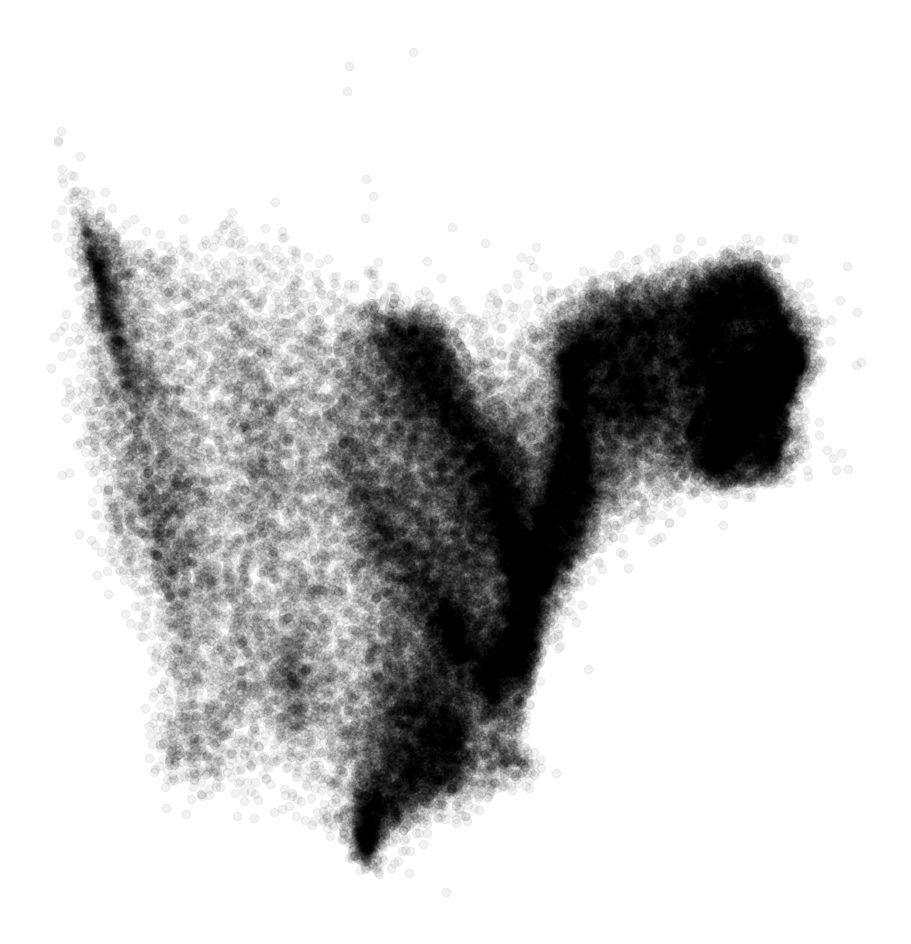

<Figure size 1000x1000 with 0 Axes>

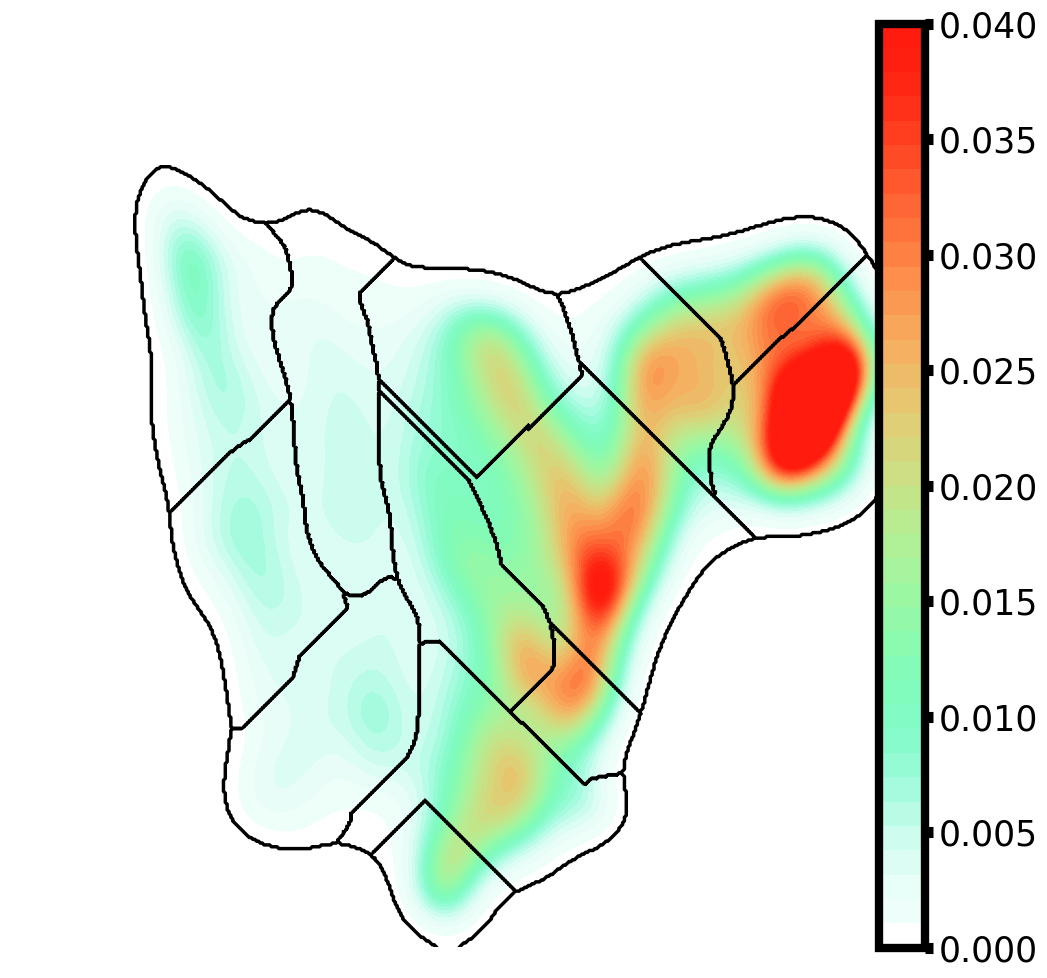

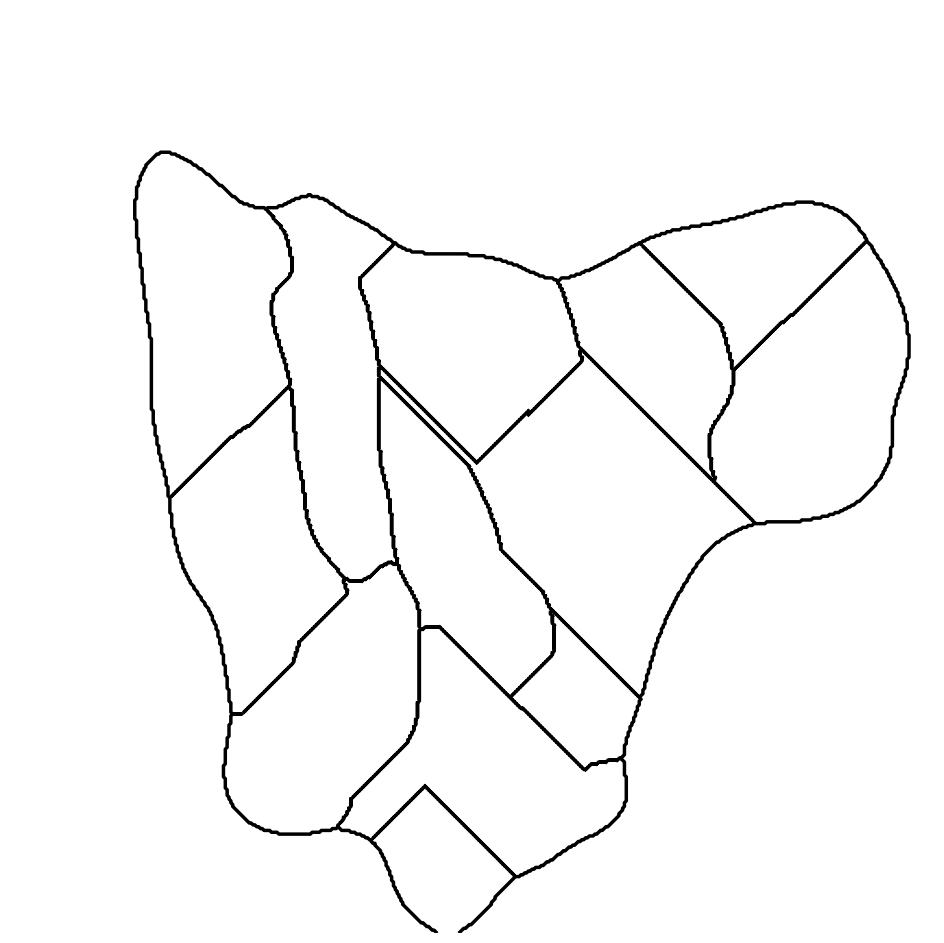

In [ ]:
# Generate embedding plots

# define colormap
orig_cmap = get_cmap('rainbow', 126)
warm_colors = orig_cmap(np.linspace(0.4, 1, 32))  # Adjust 0.2 and 0.6 based on the colormap's warm color range
white_rows = np.array([1, 1, 1, 1] * 5).reshape(5, 4)  # 5 rows of RGBA white
warm_colors = np.vstack((white_rows, np.vstack(warm_colors)))
for col in np.arange(4):
	warm_colors[:, col] = gaussian_filter(warm_colors[:, col], sigma=3)
warm_colors = np.vstack((np.array([1, 1, 1, 1]).reshape(1, 4), np.vstack(warm_colors)))
new_cmap = ListedColormap(warm_colors)

# plot raw embedding for figure-making
plt.figure(figsize=(11.5, 12))
plt.scatter(final_embs[:, 0][::150], final_embs[:, 1][::150], color='black', alpha=0.05)
plt.axis('off')
# plt.savefig('.\\retreat_figs\\embedding_blank.png', dpi=300, bbox_inches='tight')

# plot watershed embedding
plt.figure(figsize=(10,10))
final_density, _, _ = heatmap(final_embs, bins=500, sigma=10)
fig = plt.figure(figsize=(15,12))
grid = ImageGrid(fig, 111,
				nrows_ncols = (1,1),
				axes_pad = 0.05, 
				)
im = grid[0].imshow(final_density.T, cmap=new_cmap ,origin='lower', vmax=0.04)
grid[0].axis('off')
plt.colorbar(im)
plot_edges(edges, axis=0)
# plt.savefig('.\\GRC2024_figs\\watershed_embedding.svg', dpi=300, bbox_inches='tight')

# plot watershed skeleton
fig = plt.figure(figsize=(15,12))
grid = ImageGrid(fig, 111,
				nrows_ncols = (1,1),
				axes_pad = 0.05, 
				)
im = grid[0].imshow(final_density.T, cmap=new_cmap ,origin='lower', vmax=0.00)
grid[0].axis('off')
# plt.colorbar(im)
plot_edges(edges, axis=0)
# plt.savefig('.\\figures\\watershed_skeleton.png', dpi=300, bbox_inches='tight')

In [19]:
# generating individual heatmaps for each cd1 condition

# set up params for heatmaps
range = [[final_embs[:,0].min(), final_embs[:,0].max()], [final_embs[:,1].min(), final_embs[:,1].max()]]
bins = 500
sigma = 11

# define colormap
orig_cmap = get_cmap('rainbow', 126)
warm_colors = orig_cmap(np.linspace(0.4, 1, 32))  # Adjust 0.2 and 0.6 based on the colormap's warm color range
white_rows = np.array([1, 1, 1, 1] * 5).reshape(5, 4)  # 5 rows of RGBA white
warm_colors = np.vstack((white_rows, np.vstack(warm_colors)))
for col in np.arange(4):
	warm_colors[:, col] = gaussian_filter(warm_colors[:, col], sigma=3)
warm_colors = np.vstack((np.array([1, 1, 1, 1]).reshape(1, 4), np.vstack(warm_colors)))
new_cmap = ListedColormap(warm_colors)

# generate embeddings
agg_embs = []
for key in [x for x in list(data.keys()) if '_mCD1' in x if key not in ['29L', '30R2']] :
	agg_embs.append(data[key])
agg_embs = np.row_stack(agg_embs)
agg_density, _, _ = heatmap(agg_embs, bins=bins, sigma=sigma, axlims=range)

obs_embs = []
for key in [x for x in list(data.keys()) if '_OBSmCD1' in x] :
	obs_embs.append(data[key])
obs_embs = np.row_stack(obs_embs)
obs_density, _, _ = heatmap(obs_embs, bins=bins, sigma=sigma, axlims=range)

non_embs = []
for key in [x for x in list(data.keys()) if 'toyCD1' in x] :
	non_embs.append(data[key])
non_embs = np.row_stack(non_embs)
non_density, _, _ = heatmap(non_embs, bins=bins, sigma=sigma, axlims=range)

xpo_embs = []
for key in [x for x in list(data.keys()) if 'xpoCD1' in x] :
	xpo_embs.append(data[key])
xpo_embs = np.row_stack(xpo_embs)
xpo_density, _, _ = heatmap(xpo_embs, bins=bins, sigma=sigma, axlims=range)

# putting everything together
fig = plt.figure(figsize=(30,10))
grid = ImageGrid(fig, 111,
				nrows_ncols = (1,3),
				)

im = grid[0].imshow(agg_density.T, cmap=new_cmap,origin='lower', vmin=0, vmax=0.032)
grid[0].axis('off')
plot_edges(edges, axis=0)

grid[1].imshow(obs_density.T, cmap=new_cmap,origin='lower', vmin=0, vmax=0.032)
grid[1].axis('off')
plot_edges(edges, axis=1)

grid[2].imshow(xpo_density.T, cmap=new_cmap,origin='lower', vmin=0, vmax=0.032)
grid[2].axis('off')
plot_edges(edges, axis=2)

# grid[3].imshow(non_density.T, cmap=new_cmap,origin='lower', vmin=0, vmax=0.032)
# grid[3].axis('off')
# plot_edges(edges, axis=3)

# fig.colorbar(im)

cax = grid.cbar_axes[0]
axis = cax.axis[cax.orientation]
axis.label.set_rotation(270)
plt.savefig('.\\figures\\fig1\\agg_obs_non_density.svg', dpi=300, bbox_inches='tight')

NameError: name 'final_embs' is not defined

Gq keys   (7):   ['77355B_d6_CNO_t1', '77355R_d6_CNO_t1', '82017L2_d6_CNO_t1', '8605B_d6_CNO_t1', '8606L_d6_CNO_t1', '8606R2_d6_CNO_t1', '8606R_d6_CNO_t1']
Ctrl keys (7): ['GqC1_d6_CNO_t1', 'GqC2_d6_CNO_t1', 'GqC3_d6_CNO_t1', 'GqC4_d6_CNO_t1', 'GqC5_d6_CNO_t1', 'GqC6_d6_CNO_t1', 'GqC7_d6_CNO_t1']

Gq:   94952 frames
Ctrl: 91648 frames


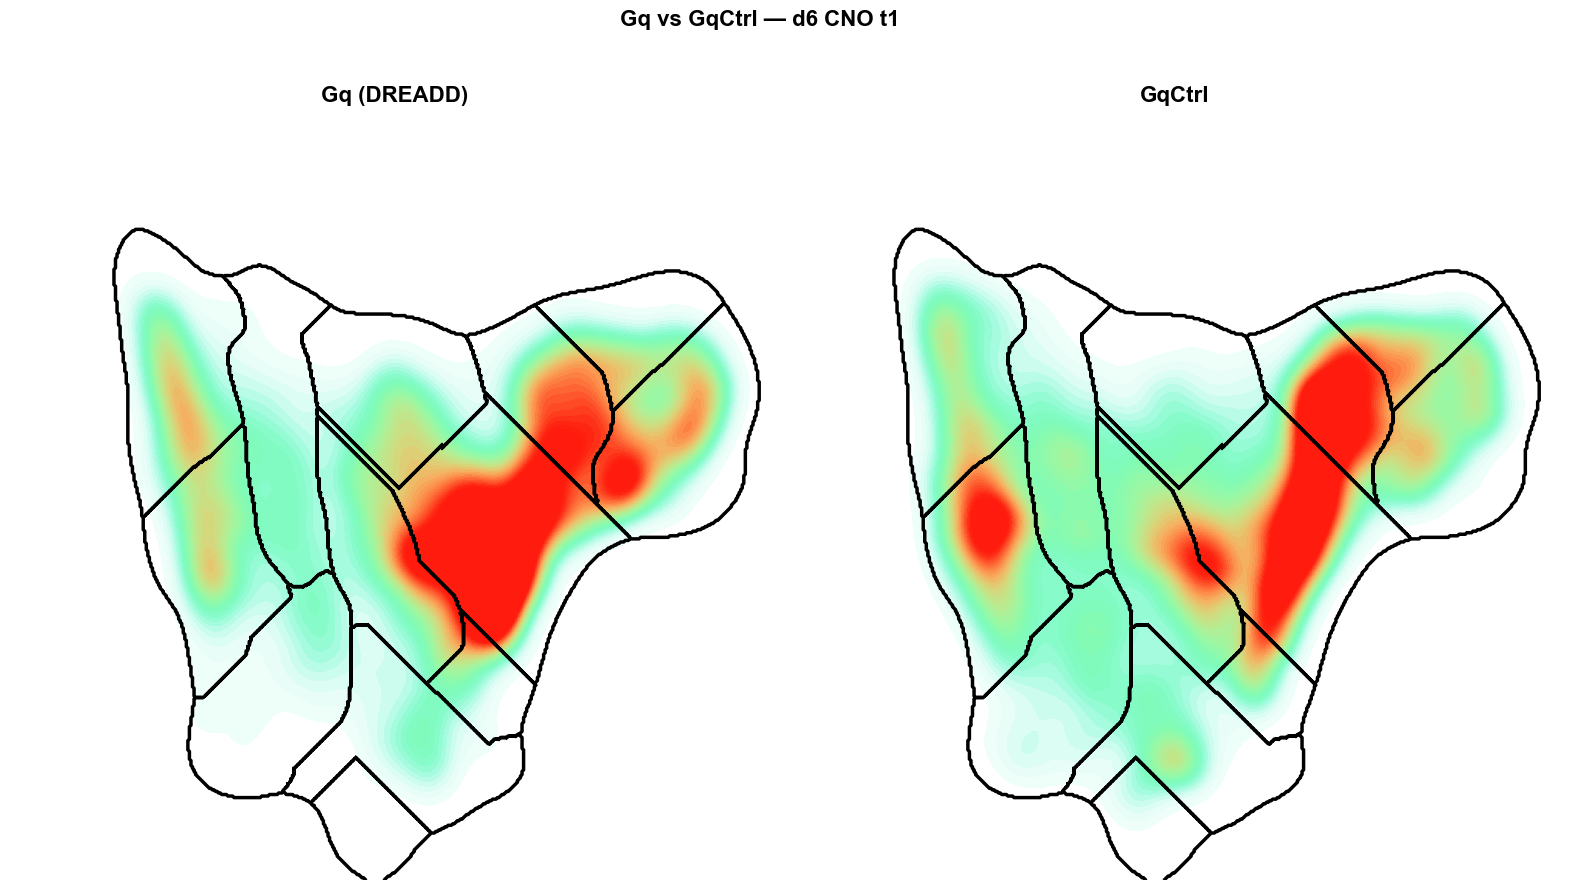

In [89]:
# ── Filter to d6_CNO_t1 only, split by group ──────────────────────────────────
gq_keys   = [k for k in other_data.keys()
             if 'd6_CNO_t1' in k and not k.startswith('GqC')]
ctrl_keys  = [k for k in other_data.keys()
              if 'd6_CNO_t1' in k and k.startswith('GqC')]

print(f'Gq keys   ({len(gq_keys)}):   {gq_keys}')
print(f'Ctrl keys ({len(ctrl_keys)}): {ctrl_keys}')

gq_embs   = np.row_stack([other_data[k] for k in gq_keys])
ctrl_embs = np.row_stack([other_data[k] for k in ctrl_keys])

gq_density,   _, _ = heatmap(gq_embs,   bins=bins, sigma=sigma, axlims=range)
ctrl_density, _, _ = heatmap(ctrl_embs, bins=bins, sigma=sigma, axlims=range)

print(f'\nGq:   {gq_embs.shape[0]} frames')
print(f'Ctrl: {ctrl_embs.shape[0]} frames')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig  = plt.figure(figsize=(20, 10))
grid = ImageGrid(fig, 111, nrows_ncols=(1, 2), axes_pad=0.1)

for ax, density, title in [
    (grid[0], gq_density,   'Gq (DREADD)'),
    (grid[1], ctrl_density, 'GqCtrl'),
]:
    im = ax.imshow(density.T, cmap=new_cmap, origin='lower',
                   vmin=0, vmax=0.032)
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', fontfamily='Arial')
    plot_edges(edges, axis=grid.axes_all.index(ax))

plt.suptitle('Gq vs GqCtrl — d6 CNO t1',
             fontsize=16, fontweight='bold', fontfamily='Arial')
plt.savefig('.\\figures\\fig1\\gq_ctrl_density.svg',
            dpi=300, bbox_inches='tight')
plt.show()

NON ref occupancy (clusters 1-13):
  C1: 4.360%
  C2: 2.346%
  C3: 3.715%
  C4: 1.231%
  C5: 0.220%
  C6: 19.952%
  C7: 2.230%
  C8: 6.553%
  C9: 2.290%
  C10: 26.399%
  C11: 3.254%
  C12: 1.391%
  C13: 26.061%

Gq keys used:   ['77355B_d6_CNO_t1', '77355B_d6_CNO_t2', '77355B_d6_CNO_t3', '77355R_d6_CNO_t1', '77355R_d6_CNO_t2', '77355R_d6_CNO_t3', '82017L2_d6_CNO_t1', '82017L2_d6_CNO_t2', '82017L2_d6_CNO_t3', '8605B_d6_CNO_t1', '8605B_d6_CNO_t2', '8605B_d6_CNO_t3', '8606L_d6_CNO_t1', '8606L_d6_CNO_t2', '8606L_d6_CNO_t3', '8606R2_d6_CNO_t1', '8606R2_d6_CNO_t2', '8606R2_d6_CNO_t3', '8606R_d6_CNO_t1', '8606R_d6_CNO_t2', '8606R_d6_CNO_t3']
Ctrl keys used: ['GqC1_d6_CNO_t1', 'GqC1_d6_CNO_t2', 'GqC1_d6_CNO_t3', 'GqC2_d6_CNO_t1', 'GqC2_d6_CNO_t2', 'GqC2_d6_CNO_t3', 'GqC3_d6_CNO_t1', 'GqC3_d6_CNO_t2', 'GqC3_d6_CNO_t3', 'GqC4_d6_CNO_t1', 'GqC4_d6_CNO_t2', 'GqC4_d6_CNO_t3', 'GqC5_d6_CNO_t1', 'GqC5_d6_CNO_t2', 'GqC5_d6_CNO_t3', 'GqC6_d6_CNO_t1', 'GqC6_d6_CNO_t2', 'GqC6_d6_CNO_t3', 'GqC7_d6_CNO_t1'

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_19316\683476040.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


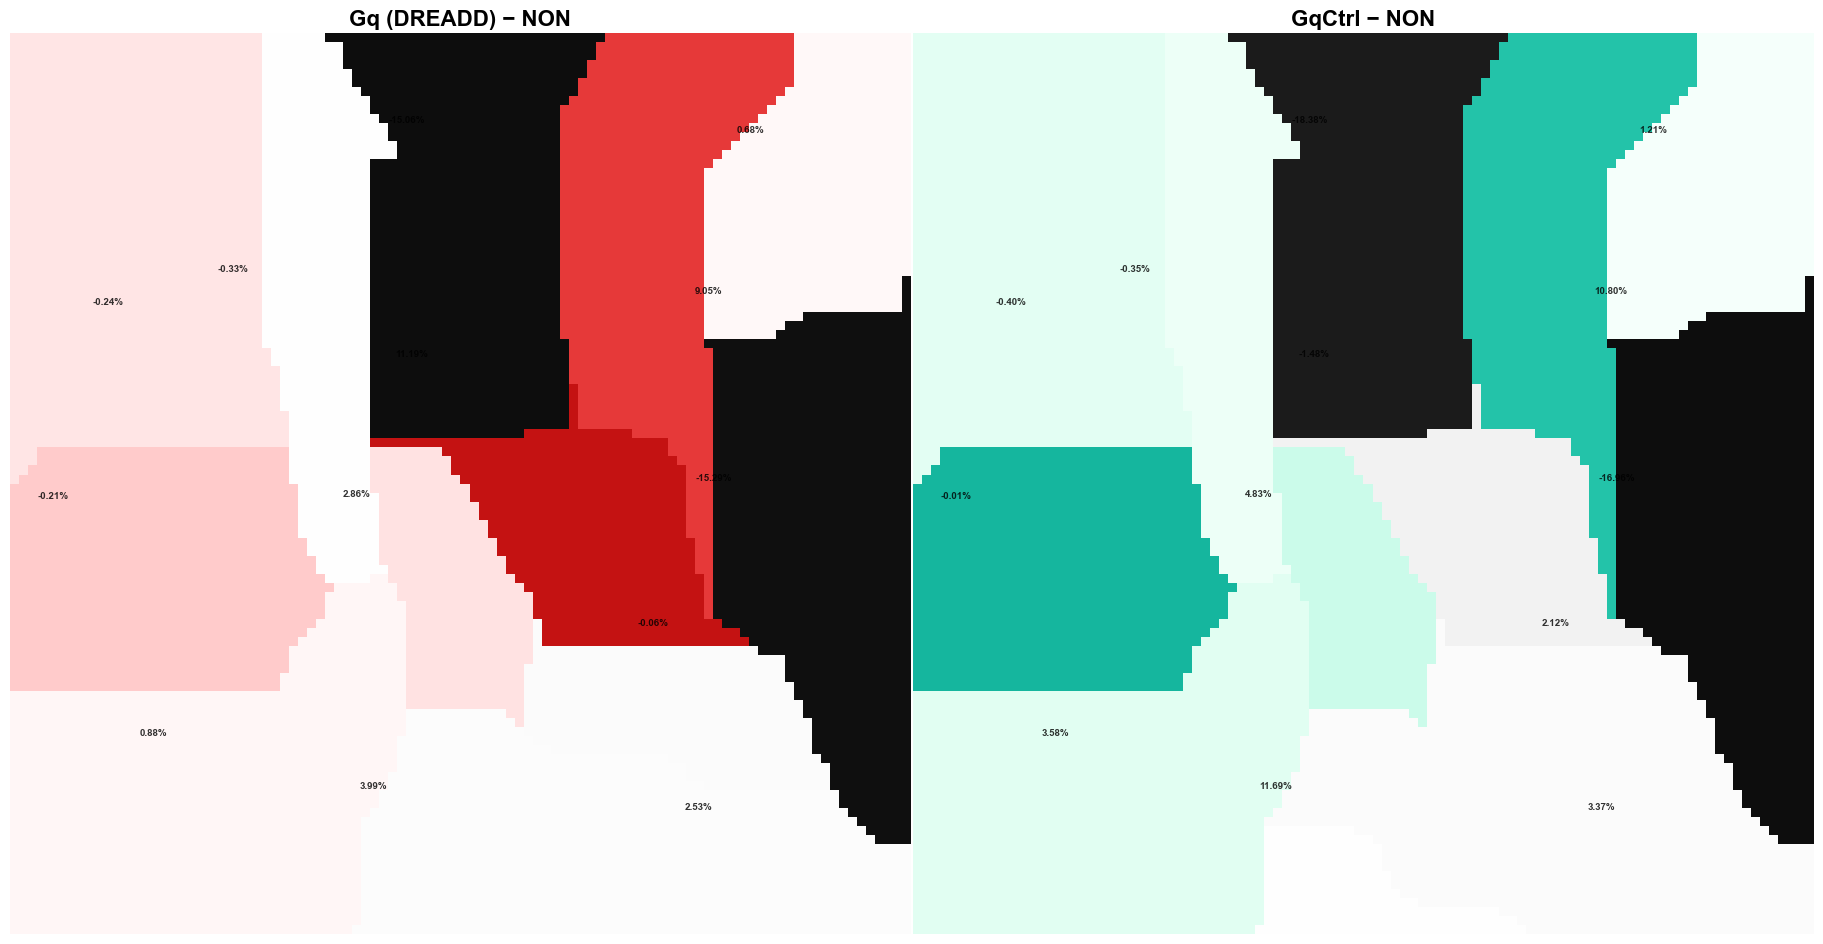


Cluster        Gq-NON %   Ctrl-NON %
------------------------------------------------------------
  C1             +2.528       +3.366
  C2             +3.992      +11.687
  C3             -0.056       +2.125
  C4             +0.875       +3.576
  C5             -0.207       -0.012
  C6            -15.290      -16.963
  C7             -0.238       -0.404
  C8             +2.865       +4.828
  C9             -0.327       -0.350
  C10           +11.191       -1.478
  C11            +9.053      +10.797
  C12            +0.676       +1.205
  C13           -15.061      -18.376


In [107]:
# ── Compute occupancies from existing labels dict ─────────────────────────────
def compute_occ_from_labels(labels_dict, key_filter, n_clusters=13):
    """
    Compute mean cluster occupancy across sessions matching key_filter.
    Returns array of shape (n_clusters+1,) — index 0 unused, 1-13 = clusters.
    """
    occ = np.zeros(n_clusters + 1)
    counts = np.zeros(n_clusters + 1)

    for key, lab in labels_dict.items():
        if not key_filter(key):
            continue
        total = len(lab)
        if total == 0:
            continue
        for c in np.arange(1, n_clusters + 1):
            occ[c]    += np.sum(lab == c) / total
            counts[c] += 1

    # average across sessions
    for c in np.arange(1, n_clusters + 1):
        if counts[c] > 0:
            occ[c] /= counts[c]

    return occ

def make_flat_difference_image(labeled_map, occ_a, occ_b,
                                neg_waypoints_rgb, pos_waypoints_rgb,
                                n_colors=256, smooth_sigma=2):
    """
    Render labeled_map as a flat diverging image where each cluster's
    fill color reflects occ_a - occ_b:
    - Positive (a > b): pos_waypoints colors
    - Negative (a < b): neg_waypoints colors
    - Zero: white
    Color intensity scaled by magnitude of difference.
    """
    def build_half_palette(waypoints, n):
        pts   = np.array([[r, g, b, 1.0] for r, g, b in waypoints])
        x_in  = np.linspace(0, 1, len(pts))
        x_out = np.linspace(0, 1, n)
        pal   = np.stack([
            np.interp(x_out, x_in, pts[:, ch])
            for ch in np.arange(4)
        ], axis=1)
        for ch in np.arange(4):
            pal[:, ch] = gaussian_filter(pal[:, ch], sigma=smooth_sigma)
            pal[:, ch] = np.clip(pal[:, ch], 0, 1)
        return pal

    neg_palette = build_half_palette(neg_waypoints_rgb, n_colors)  # neg end -> white
    pos_palette = build_half_palette(pos_waypoints_rgb, n_colors)  # white -> pos end

    # Compute per-cluster differences (clusters 1-13)
    diff = occ_a[1:] - occ_b[1:]  # shape (13,)

    # Normalize by shared absolute max for symmetric scaling
    abs_max = np.abs(diff).max() + 1e-10
    diff_norm = diff / abs_max  # range [-1, 1]

    # Build RGBA image
    h, w     = labeled_map.shape
    img_rgba = np.ones((h, w, 4))  # default white

    for c_idx, c in enumerate(np.arange(1, 14)):
        mask = labeled_map == c
        d    = diff_norm[c_idx]

        if d >= 0:
            # Positive: sample from pos_palette
            color_idx = int(d * (n_colors - 1))
            color     = pos_palette[color_idx]
        else:
            # Negative: sample from neg_palette (reversed — most negative = index 0)
            color_idx = int((1 + d) * (n_colors - 1))  # d is negative so 1+d < 1
            color     = neg_palette[color_idx]

        img_rgba[mask] = color

    return img_rgba, diff

# ── Filter keys ───────────────────────────────────────────────────────────────
# NON: d9_toyCD1 sessions from existing labels dict
occ_non_ref = compute_occ_from_labels(
    labels,
    key_filter=lambda k: 'd9_toyCD1' in k or '_toyCD1_' in k
)

# Gq DREADD: numeric ID, d6_CNO_t1
occ_gq = compute_occ_from_labels(
    labels_C,
    key_filter=lambda k: 'd6_CNO_t1' in k and not k.startswith('GqC')
)

# GqCtrl: starts with GqC, d6_CNO_t1
occ_ctrl = compute_occ_from_labels(
    labels_C,
    key_filter=lambda k: 'd6_CNO_t1' in k and k.startswith('GqC') and 'GqC3' not in k
)

print('NON ref occupancy (clusters 1-13):')
for c in np.arange(1, 14):
    print(f'  C{c}: {occ_non_ref[c]*100:.3f}%')
print(f'\nGq keys used:   {[k for k in labels_C if "d6_CNO" in k and not k.startswith("GqC")]}')
print(f'Ctrl keys used: {[k for k in labels_C if "d6_CNO" in k and k.startswith("GqC")]}')


# ── Difference maps: Gq − NON and GqCtrl − NON ───────────────────────────────
img_diff_gq_non, diff_gq_non = make_flat_difference_image(
    labeled_map, occ_gq, occ_non_ref,
    neg_waypoints_rgb=[          # negative = NON > Gq (gray)
        (0.05, 0.05, 0.05),
        (0.20, 0.20, 0.20),
        (0.40, 0.40, 0.40),
        (0.65, 0.65, 0.65),
        (0.88, 0.88, 0.88),
        (1.00, 1.00, 1.00),
    ],
    pos_waypoints_rgb=[          # positive = Gq > NON (red)
        (1.00, 1.00, 1.00),
        (1.00, 0.88, 0.88),
        (1.00, 0.60, 0.60),
        (0.90, 0.20, 0.20),
        (0.70, 0.00, 0.00),
        (0.45, 0.00, 0.00),
    ],
)

img_diff_ctrl_non, diff_ctrl_non = make_flat_difference_image(
    labeled_map, occ_ctrl, occ_non_ref,
    neg_waypoints_rgb=[          # negative = NON > Ctrl (gray)
        (0.05, 0.05, 0.05),
        (0.20, 0.20, 0.20),
        (0.40, 0.40, 0.40),
        (0.65, 0.65, 0.65),
        (0.88, 0.88, 0.88),
        (1.00, 1.00, 1.00),
    ],
    pos_waypoints_rgb=[          # positive = Ctrl > NON (teal)
        (1.00, 1.00, 1.00),
        (0.88, 1.00, 0.95),
        (0.60, 0.95, 0.85),
        (0.10, 0.75, 0.65),
        (0.00, 0.55, 0.48),
        (0.00, 0.35, 0.30),
    ],
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig  = plt.figure(figsize=(20, 10))
grid = ImageGrid(fig, 111, nrows_ncols=(1, 2))

for ax, img, diff_vals, title in [
    (grid[0], img_diff_gq_non,   diff_gq_non,   'Gq (DREADD) − NON'),
    (grid[1], img_diff_ctrl_non, diff_ctrl_non, 'GqCtrl − NON'),
]:
    ax.imshow(img.transpose(1, 0, 2), origin='lower')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', fontfamily='Arial')

    for c_idx, c in enumerate(np.arange(1, 14)):
        x = np.mean(np.where(labeled_map == c)[0])
        y = np.mean(np.where(labeled_map == c)[1])
        ax.text(y, x, f'{diff_vals[c_idx]*100:.2f}%',
                ha='center', va='center', fontsize=7,
                fontweight='bold', fontfamily='Arial',
                color='black', alpha=0.8)

plt.tight_layout()
plt.savefig('.\\figures\\fig1\\flat_diff_gq_ctrl_vs_non.svg',
            dpi=300, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'{"Cluster":<10} {"Gq-NON %":>12} {"Ctrl-NON %":>12}')
print('-'*60)
for c_idx in np.arange(13):
    print(f'  C{c_idx+1:<7} '
          f'{diff_gq_non[c_idx]*100:>+12.3f} '
          f'{diff_ctrl_non[c_idx]*100:>+12.3f}')

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_19316\2765798584.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


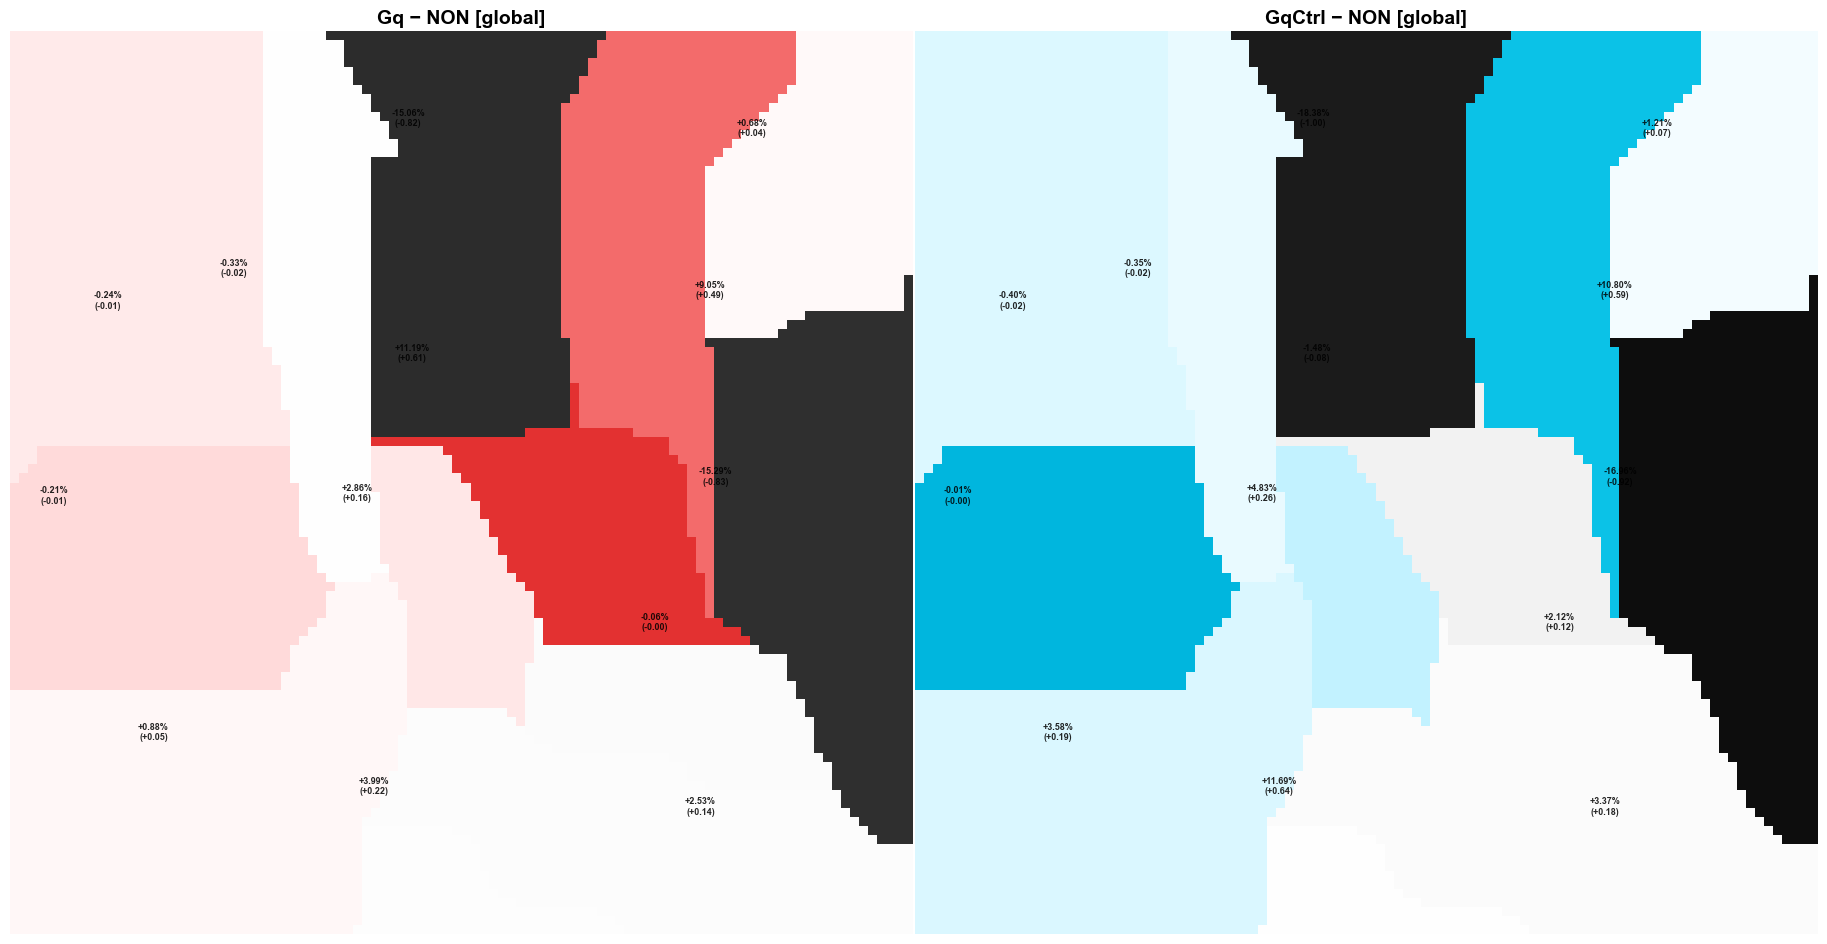

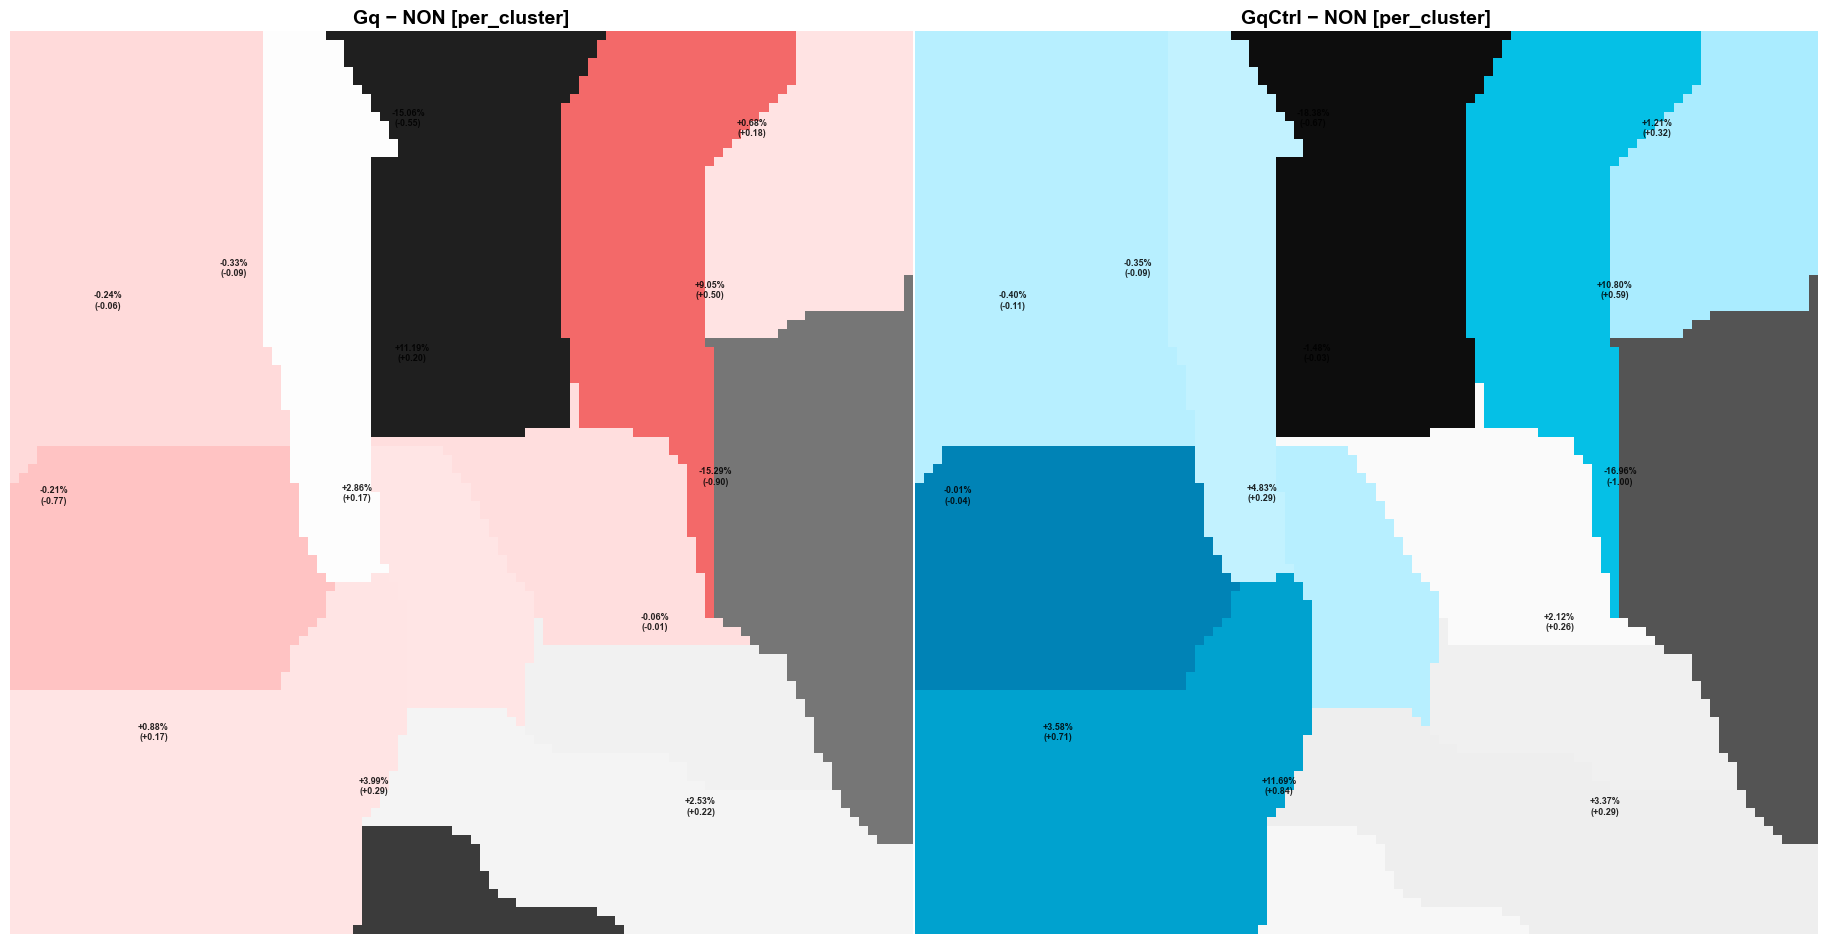

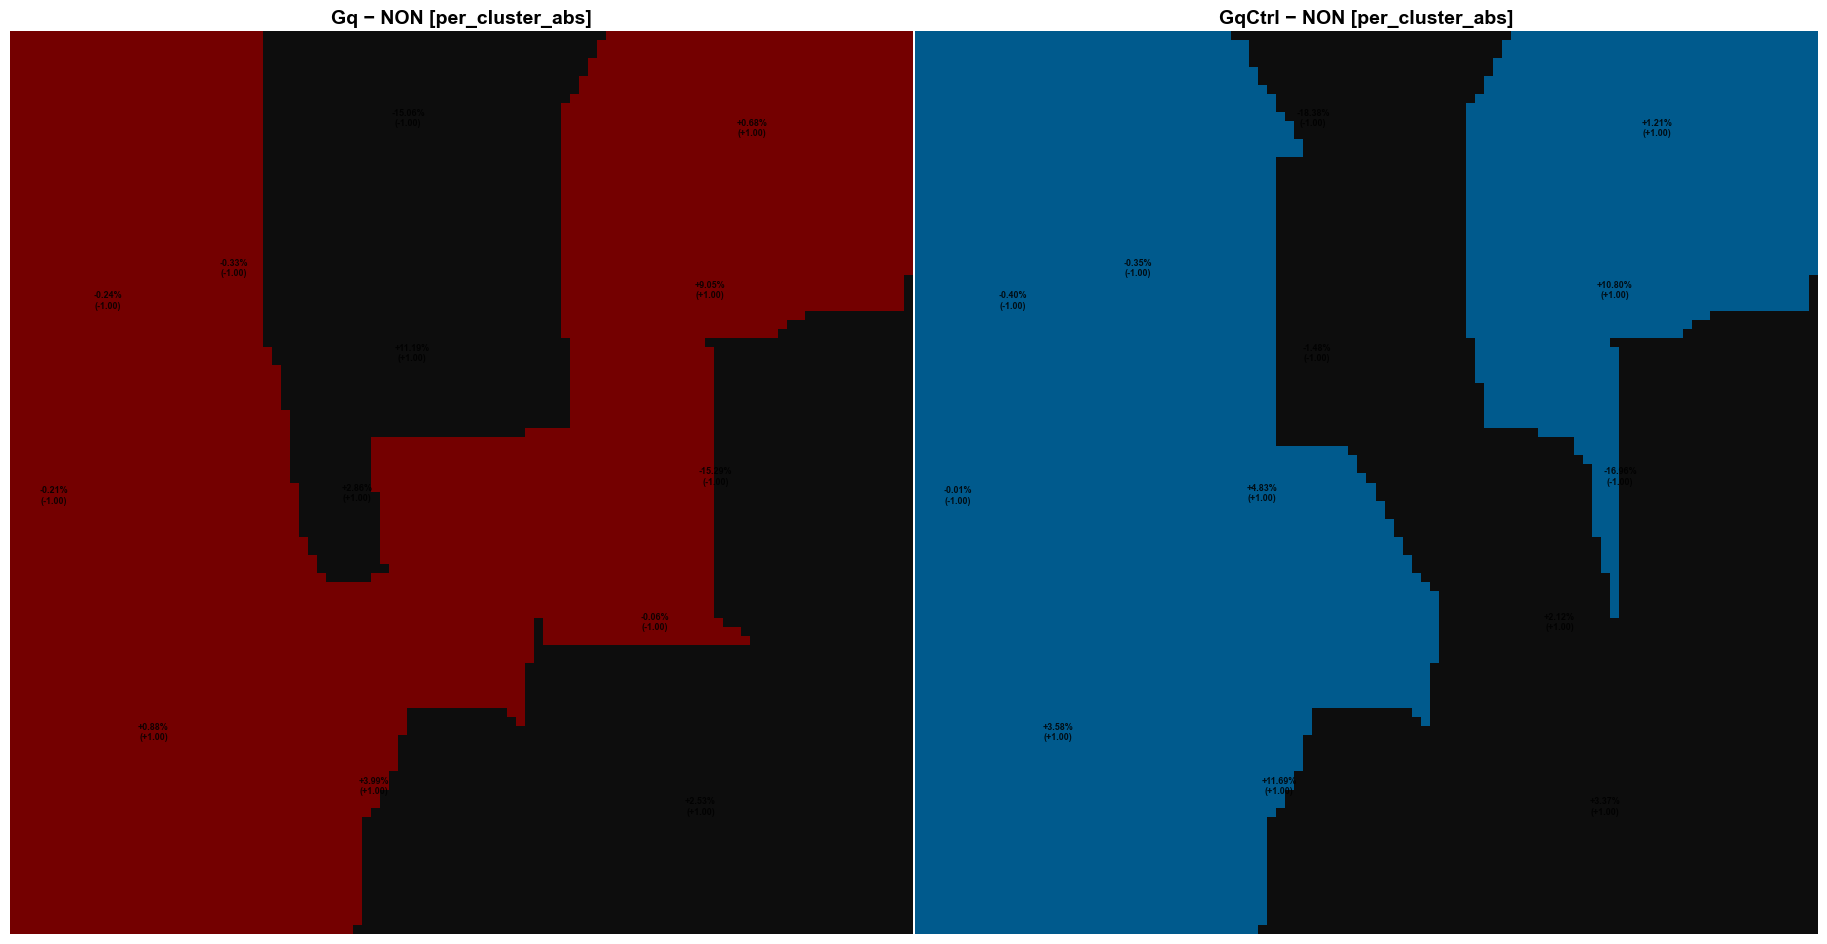


Cluster       Gq-NON%     norm  Ctrl-NON%     norm  Mean occ%
-------------------------------------------------------------------------------------
  C1           +2.528   +1.000     +3.366   +1.000      6.325
  C2           +3.992   +1.000    +11.687   +1.000      7.572
  C3           -0.056   -1.000     +2.125   +1.000      4.405
  C4           +0.875   +1.000     +3.576   +1.000      2.715
  C5           -0.207   -1.000     -0.012   -1.000      0.147
  C6          -15.290   -1.000    -16.963   -1.000      9.201
  C7           -0.238   -1.000     -0.404   -1.000      2.015
  C8           +2.865   +1.000     +4.828   +1.000      9.117
  C9           -0.327   -1.000     -0.350   -1.000      2.064
  C10         +11.191   +1.000     -1.478   -1.000     29.636
  C11          +9.053   +1.000    +10.797   +1.000      9.870
  C12          +0.676   +1.000     +1.205   +1.000      2.018
  C13         -15.061   -1.000    -18.376   -1.000     14.915

Group                            Gq−NON %   

In [108]:
def make_flat_difference_image(labeled_map, occ_a, occ_b,
                                neg_waypoints_rgb, pos_waypoints_rgb,
                                n_colors=256, smooth_sigma=2,
                                normalization='per_cluster',
                                occ_all_groups=None,
                                shared_abs_max=None):
    def build_half_palette(waypoints, n):
        pts   = np.array([[r, g, b, 1.0] for r, g, b in waypoints])
        x_in  = np.linspace(0, 1, len(pts))
        x_out = np.linspace(0, 1, n)
        pal   = np.stack([
            np.interp(x_out, x_in, pts[:, ch])
            for ch in np.arange(4)
        ], axis=1)
        for ch in np.arange(4):
            pal[:, ch] = gaussian_filter(pal[:, ch], sigma=smooth_sigma)
            pal[:, ch] = np.clip(pal[:, ch], 0, 1)
        return pal

    neg_palette = build_half_palette(neg_waypoints_rgb, n_colors)
    pos_palette = build_half_palette(pos_waypoints_rgb, n_colors)

    diff = occ_a[1:] - occ_b[1:]

    if normalization == 'global':
        abs_max   = shared_abs_max if shared_abs_max is not None \
                    else np.abs(diff).max() + 1e-10
        diff_norm = diff / abs_max

    elif normalization == 'per_cluster':
        if occ_all_groups is not None:
            grand_mean = np.mean(
                np.stack([o[1:] for o in occ_all_groups], axis=0), axis=0)
        else:
            grand_mean = (occ_a[1:] + occ_b[1:]) / 2.0
        rel_diff  = diff / (grand_mean + 1e-10)
        abs_max   = shared_abs_max if shared_abs_max is not None \
                    else np.abs(rel_diff).max() + 1e-10
        diff_norm = rel_diff / abs_max

    elif normalization == 'per_cluster_abs':
        per_abs   = np.abs(diff) + 1e-10
        diff_norm = diff / per_abs

    else:
        raise ValueError(f'Unknown normalization: {normalization}')

    h, w     = labeled_map.shape
    img_rgba = np.ones((h, w, 4))

    for c_idx, c in enumerate(np.arange(1, 14)):
        mask = labeled_map == c
        d    = np.clip(diff_norm[c_idx], -1, 1)
        if d >= 0:
            color_idx = int(d * (n_colors - 1))
            color     = pos_palette[color_idx]
        else:
            color_idx = int((1 + d) * (n_colors - 1))
            color     = neg_palette[color_idx]
        img_rgba[mask] = color

    return img_rgba, diff, diff_norm


# ── Shared setup ───────────────────────────────────────────────────────────────
all_occs_cno = [occ_gq, occ_ctrl, occ_non_ref]
grand_mean_cno = np.mean(
    np.stack([o[1:] for o in all_occs_cno], axis=0), axis=0)

diff_gq_non_raw   = occ_gq[1:]   - occ_non_ref[1:]
diff_ctrl_non_raw = occ_ctrl[1:] - occ_non_ref[1:]

# ── Color specs ────────────────────────────────────────────────────────────────
# Gq vs NON: red (Gq > NON) vs gray (NON > Gq)
gq_non_colors = dict(
    neg_waypoints_rgb=[          # negative = NON > Gq (gray)
        (0.05, 0.05, 0.05), (0.20, 0.20, 0.20), (0.40, 0.40, 0.40),
        (0.65, 0.65, 0.65), (0.88, 0.88, 0.88), (1.00, 1.00, 1.00),
    ],
    pos_waypoints_rgb=[          # positive = Gq > NON (red)
        (1.00, 1.00, 1.00), (1.00, 0.88, 0.88), (1.00, 0.60, 0.60),
        (0.90, 0.20, 0.20), (0.70, 0.00, 0.00), (0.45, 0.00, 0.00),
    ],
)

# Ctrl vs NON: cyan (Ctrl > NON) vs gray (NON > Ctrl)
ctrl_non_colors = dict(
    neg_waypoints_rgb=[          # negative = NON > Ctrl (gray)
        (0.05, 0.05, 0.05), (0.20, 0.20, 0.20), (0.40, 0.40, 0.40),
        (0.65, 0.65, 0.65), (0.88, 0.88, 0.88), (1.00, 1.00, 1.00),
    ],
    pos_waypoints_rgb=[          # positive = Ctrl > NON (cyan)
        (1.00, 1.00, 1.00), (0.85, 0.97, 1.00), (0.55, 0.90, 1.00),
        (0.00, 0.75, 0.90), (0.00, 0.55, 0.75), (0.00, 0.35, 0.55),
    ],
)

# ── Loop over normalization methods ───────────────────────────────────────────
for norm_method in ['global', 'per_cluster', 'per_cluster_abs']:

    if norm_method == 'global':
        shared_abs_max = max(
            np.abs(diff_gq_non_raw).max(),
            np.abs(diff_ctrl_non_raw).max(),
        ) + 1e-10

    elif norm_method == 'per_cluster':
        shared_abs_max = max(
            np.abs(diff_gq_non_raw   / (grand_mean_cno + 1e-10)).max(),
            np.abs(diff_ctrl_non_raw / (grand_mean_cno + 1e-10)).max(),
        ) + 1e-10

    else:
        shared_abs_max = None

    img_diff_gq_non, diff_gq_non, diff_norm_gq_non = make_flat_difference_image(
        labeled_map, occ_gq, occ_non_ref, **gq_non_colors,
        normalization=norm_method, occ_all_groups=all_occs_cno,
        shared_abs_max=shared_abs_max,
    )
    img_diff_ctrl_non, diff_ctrl_non, diff_norm_ctrl_non = make_flat_difference_image(
        labeled_map, occ_ctrl, occ_non_ref, **ctrl_non_colors,
        normalization=norm_method, occ_all_groups=all_occs_cno,
        shared_abs_max=shared_abs_max,
    )

    fig  = plt.figure(figsize=(20, 10))
    grid = ImageGrid(fig, 111, nrows_ncols=(1, 2))

    for ax, img, diff_vals, diff_norm_vals, title in [
        (grid[0], img_diff_gq_non,   diff_gq_non,   diff_norm_gq_non,   'Gq − NON'),
        (grid[1], img_diff_ctrl_non, diff_ctrl_non, diff_norm_ctrl_non, 'GqCtrl − NON'),
    ]:
        ax.imshow(img.transpose(1, 0, 2), origin='lower')
        ax.axis('off')
        ax.set_title(f'{title} [{norm_method}]',
                     fontsize=14, fontweight='bold', fontfamily='Arial')

        for c_idx, c in enumerate(np.arange(1, 14)):
            x = np.mean(np.where(labeled_map == c)[0])
            y = np.mean(np.where(labeled_map == c)[1])
            ax.text(y, x,
                    f'{diff_vals[c_idx]*100:+.2f}%\n({diff_norm_vals[c_idx]:+.2f})',
                    ha='center', va='center', fontsize=6.5,
                    fontweight='bold', fontfamily='Arial',
                    color='black', alpha=0.85)

    plt.tight_layout()
    plt.savefig(f'.\\figures\\fig1\\flat_diff_cno_{norm_method}.svg',
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# ── Summary table ──────────────────────────────────────────────────────────────
print(f'\n{"="*85}')
print(f'{"Cluster":<10} {"Gq-NON%":>10} {"norm":>8} '
      f'{"Ctrl-NON%":>10} {"norm":>8} {"Mean occ%":>10}')
print('-'*85)
mean_occ_cno = (occ_gq[1:] + occ_ctrl[1:] + occ_non_ref[1:]) / 3
for c_idx in np.arange(13):
    print(f'  C{c_idx+1:<7} '
          f'{diff_gq_non[c_idx]*100:>+10.3f} '
          f'{diff_norm_gq_non[c_idx]:>+8.3f} '
          f'{diff_ctrl_non[c_idx]*100:>+10.3f} '
          f'{diff_norm_ctrl_non[c_idx]:>+8.3f} '
          f'{mean_occ_cno[c_idx]*100:>10.3f}')

# ── Cluster group averages ─────────────────────────────────────────────────────
cluster_groups = {
    'Clusters 1–4':           [1, 2, 3, 4],
    'Clusters 5,7,8,9':       [5, 7, 8, 9],
    'Clusters 6,10,11,12,13': [6, 10, 11, 12, 13],
}

print(f'\n{"="*55}')
print(f'{"Group":<28} {"Gq−NON %":>12} {"Ctrl−NON %":>12}')
print('-'*55)
for group_name, cluster_ids in cluster_groups.items():
    idxs      = [c - 1 for c in cluster_ids]
    mean_gq   = np.mean(diff_gq_non[idxs])   * 100
    mean_ctrl = np.mean(diff_ctrl_non[idxs]) * 100
    print(f'  {group_name:<26} {mean_gq:>+12.3f} {mean_ctrl:>+12.3f}')
print('='*55)